In [3]:
print(len(raw), len(tr))
print(raw.head())
print(tr.head())
print(sorted(raw["sample"].tolist())[:10])
print(sorted(tr["sample"].tolist())[:10])

16 16
        sample     reads  len
0  CD56_S2.raw  32549200  150
1   CD4_S1.raw  28469446  150
2  CD14_S2.raw  36356801  150
3  CD19_S2.raw  28719495  150
4   CD4_S4.raw  28835978  150
         sample     reads    len
0  CD19_S3.trim  30880981  8-100
1  CD14_S4.trim  36882410  8-100
2  CD19_S2.trim  28532892  8-100
3  CD56_S4.trim  29993175  8-100
4  CD19_S1.trim  30612117  8-100
['CD14_S1.raw', 'CD14_S2.raw', 'CD14_S3.raw', 'CD14_S4.raw', 'CD19_S1.raw', 'CD19_S2.raw', 'CD19_S3.raw', 'CD19_S4.raw', 'CD4_S1.raw', 'CD4_S2.raw']
['CD14_S1.trim', 'CD14_S2.trim', 'CD14_S3.trim', 'CD14_S4.trim', 'CD19_S1.trim', 'CD19_S2.trim', 'CD19_S3.trim', 'CD19_S4.trim', 'CD4_S1.trim', 'CD4_S2.trim']


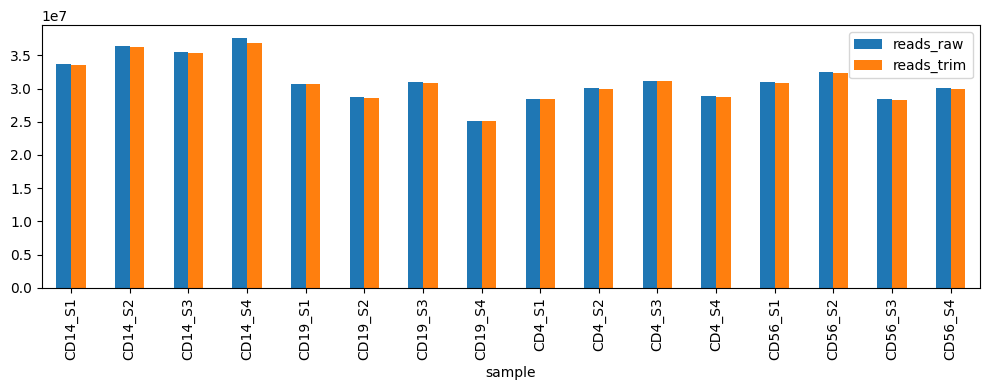

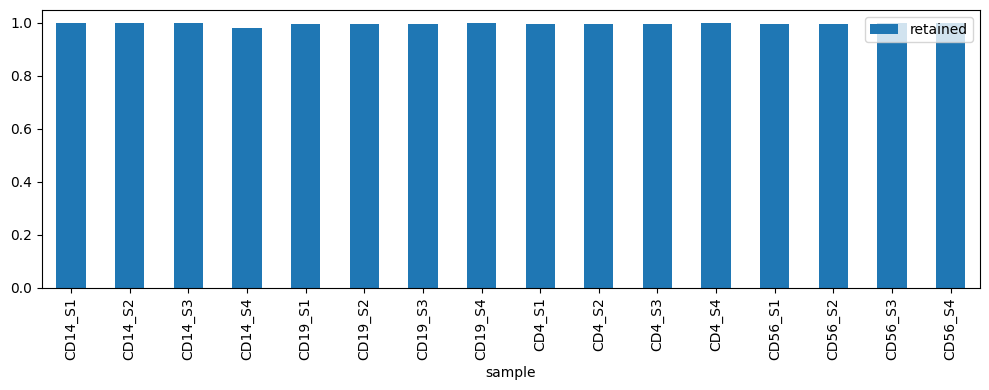

,sample,reads_raw,len_raw,reads_trim,len_trim,retained
7,CD14_S1,33666454,150,33606041,8-100,0.998206
2,CD14_S2,36356801,150,36279556,8-100,0.997875
15,CD14_S3,35451156,150,35365237,8-100,0.997576
13,CD14_S4,37654239,150,36882410,8-100,0.979502
6,CD19_S1,30739877,150,30612117,8-100,0.995844
3,CD19_S2,28719495,150,28532892,8-100,0.993503
10,CD19_S3,30978625,150,30880981,8-100,0.996848
11,CD19_S4,25183389,150,25120029,8-100,0.997484
1,CD4_S1,28469446,150,28374651,8-100,0.996670
9,CD4_S2,30104067,150,29963671,8-100,0.995336


In [5]:
from pathlib import Path; import zipfile,pandas as pd,matplotlib.pyplot as plt
R=Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq")

def norm(s):
    return s.replace("_fastqc","").replace(".fastq.gz","").replace(".gz","").replace(".raw","").replace(".trim","")

def fq(z):
    with zipfile.ZipFile(z) as h:
        t=[n for n in h.namelist() if n.endswith("fastqc_data.txt")][0]
        x=h.read(t).decode().splitlines()
    d={}; sec=None
    for l in x:
        if l.startswith(">>"): sec=None if "END_MODULE" in l else l[2:].split("\t")[0]
        elif sec=="Basic Statistics" and l and not l.startswith("#"):
            a=l.split("\t"); d[a[0]]=a[1]
    return {"sample":norm(z.stem),"reads":int(d["Total Sequences"]),"len":d["Sequence length"]}

raw=pd.DataFrame([fq(x) for x in (R/"fastqc/raw").glob("*.zip")])
tr=pd.DataFrame([fq(x) for x in (R/"fastqc/trimmed").glob("*.zip")])
m=raw.merge(tr,on="sample",suffixes=("_raw","_trim")).sort_values("sample")
m["retained"]=m.reads_trim/m.reads_raw

m.plot(x="sample",y=["reads_raw","reads_trim"],kind="bar",figsize=(10,4)); plt.tight_layout(); plt.show()
m.plot(x="sample",y="retained",kind="bar",figsize=(10,4)); plt.tight_layout(); plt.show()
m

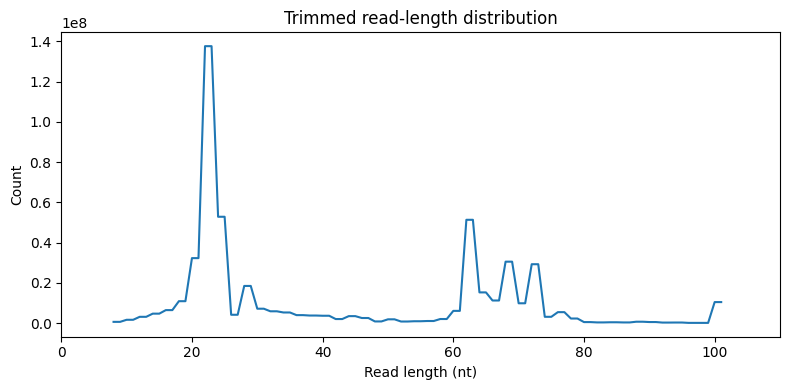

In [5]:
from pathlib import Path
import zipfile, pandas as pd, matplotlib.pyplot as plt

R = Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq")

def norm(s):
    return s.replace("_fastqc","").replace(".fastq.gz","").replace(".gz","").replace(".raw","").replace(".trim","")

def expand_len(x):
    x = str(x)
    if "-" in x:
        a,b = x.split("-")
        return list(range(int(a), int(b)+1))
    return [int(x)]

def parse_len(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        t = [n for n in z.namelist() if n.endswith("fastqc_data.txt")][0]
        lines = z.read(t).decode().splitlines()
    sec, keep = None, []
    for l in lines:
        if l.startswith(">>"):
            sec = None if "END_MODULE" in l else l[2:].split("\t")[0]
        elif sec == "Sequence Length Distribution" and l and not l.startswith("#"):
            keep.append(l.split("\t"))
    rows = []
    for k,v in keep:
        for L in expand_len(k):
            rows.append({"sample": norm(zip_path.stem), "length": L, "count": float(v)})
    return pd.DataFrame(rows)

trim_len = pd.concat([parse_len(x) for x in (R/"fastqc/trimmed").glob("*.zip")], ignore_index=True)
agg = trim_len.groupby("length", as_index=False)["count"].sum()

plt.figure(figsize=(8,4))
plt.plot(agg["length"], agg["count"])
plt.xlim(0, 110)
plt.xlabel("Read length (nt)")
plt.ylabel("Count")
plt.title("Trimmed read-length distribution")
plt.tight_layout()
plt.show()

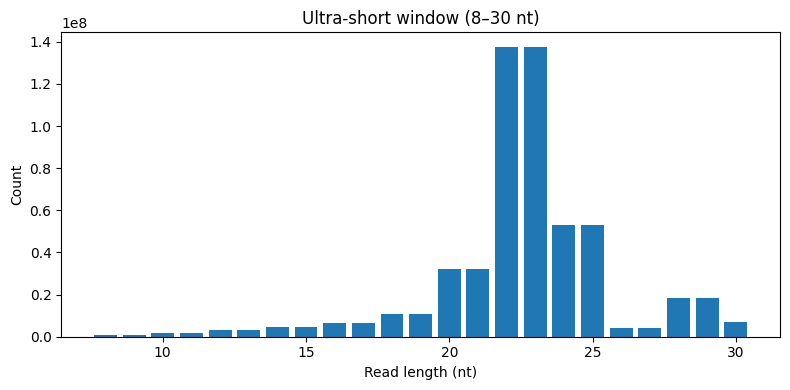

In [6]:
zoom = agg[(agg["length"] >= 8) & (agg["length"] <= 30)]

plt.figure(figsize=(8,4))
plt.bar(zoom["length"], zoom["count"])
plt.xlabel("Read length (nt)")
plt.ylabel("Count")
plt.title("Ultra-short window (8–30 nt)")
plt.tight_layout()
plt.show()

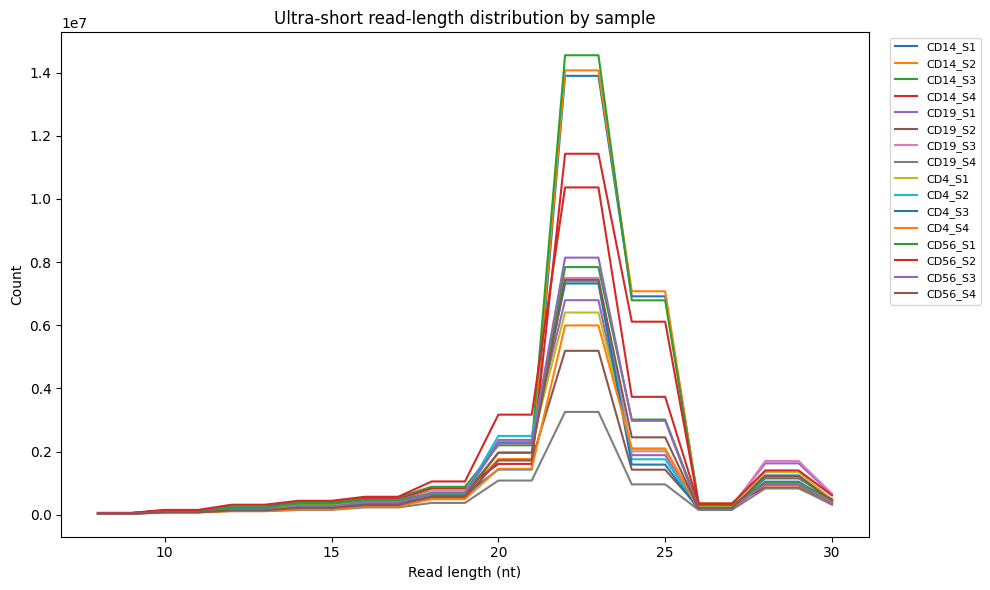

In [7]:
from pathlib import Path
import zipfile, pandas as pd, matplotlib.pyplot as plt

R = Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq")

def norm(s):
    return s.replace("_fastqc","").replace(".fastq.gz","").replace(".gz","").replace(".raw","").replace(".trim","")

def expand_len(x):
    x = str(x)
    if "-" in x:
        a,b = x.split("-")
        return list(range(int(a), int(b)+1))
    return [int(x)]

def parse_len(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        t = [n for n in z.namelist() if n.endswith("fastqc_data.txt")][0]
        lines = z.read(t).decode().splitlines()
    sec, keep = None, []
    for l in lines:
        if l.startswith(">>"):
            sec = None if "END_MODULE" in l else l[2:].split("\t")[0]
        elif sec == "Sequence Length Distribution" and l and not l.startswith("#"):
            keep.append(l.split("\t"))
    rows = []
    for k,v in keep:
        for L in expand_len(k):
            rows.append({"sample": norm(zip_path.stem), "length": L, "count": float(v)})
    return pd.DataFrame(rows)

trim_len = pd.concat([parse_len(x) for x in (R/"fastqc/trimmed").glob("*.zip")], ignore_index=True)

plt.figure(figsize=(10,6))
for s, df in trim_len.groupby("sample"):
    df = df[(df["length"] >= 8) & (df["length"] <= 30)]
    plt.plot(df["length"], df["count"], label=s)
plt.xlabel("Read length (nt)")
plt.ylabel("Count")
plt.title("Ultra-short read-length distribution by sample")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

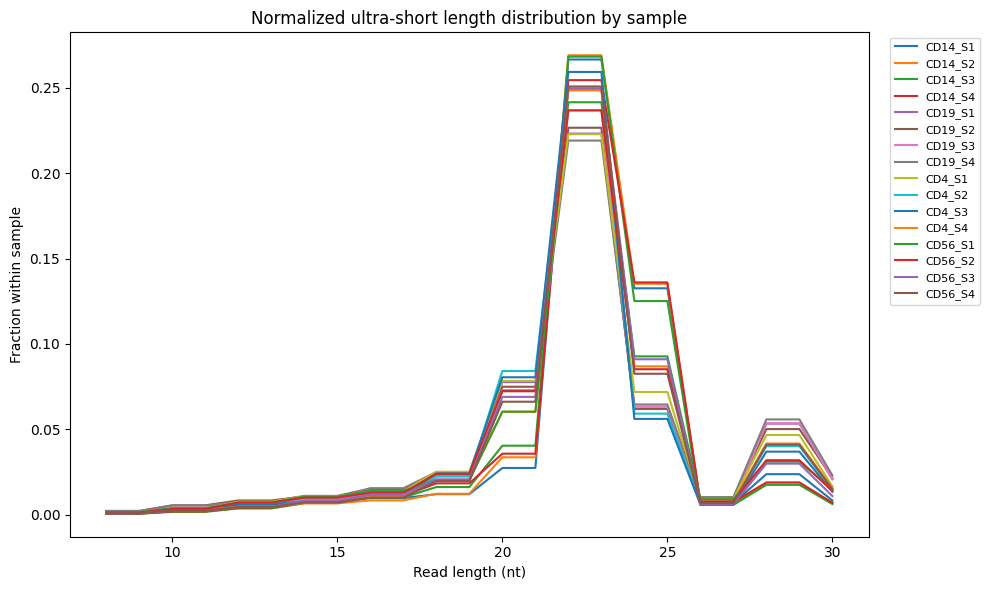

In [8]:
norm_df = trim_len[(trim_len["length"] >= 8) & (trim_len["length"] <= 30)].copy()
norm_df["frac"] = norm_df.groupby("sample")["count"].transform(lambda x: x / x.sum())

plt.figure(figsize=(10,6))
for s, df in norm_df.groupby("sample"):
    plt.plot(df["length"], df["frac"], label=s)
plt.xlabel("Read length (nt)")
plt.ylabel("Fraction within sample")
plt.title("Normalized ultra-short length distribution by sample")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

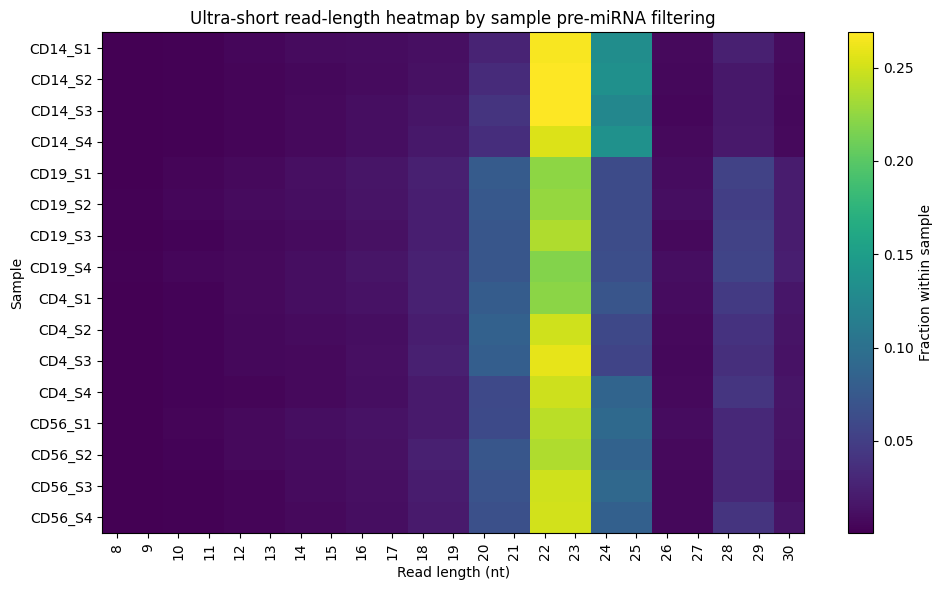

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# keep only ultra-short window
hm = trim_len[(trim_len["length"] >= 8) & (trim_len["length"] <= 30)].copy()

# use fractions within each sample so depth doesn't dominate
hm["frac"] = hm.groupby("sample")["count"].transform(lambda x: x / x.sum())

# sample x length matrix
mat = hm.pivot_table(index="sample", columns="length", values="frac", fill_value=0)

plt.figure(figsize=(10,6))
plt.imshow(mat, aspect="auto")
plt.yticks(range(len(mat.index)), mat.index)
plt.xticks(range(len(mat.columns)), mat.columns, rotation=90)
plt.colorbar(label="Fraction within sample")
plt.xlabel("Read length (nt)")
plt.ylabel("Sample")
plt.title("Ultra-short read-length heatmap by sample pre-miRNA filtering")
plt.tight_layout()
plt.show()

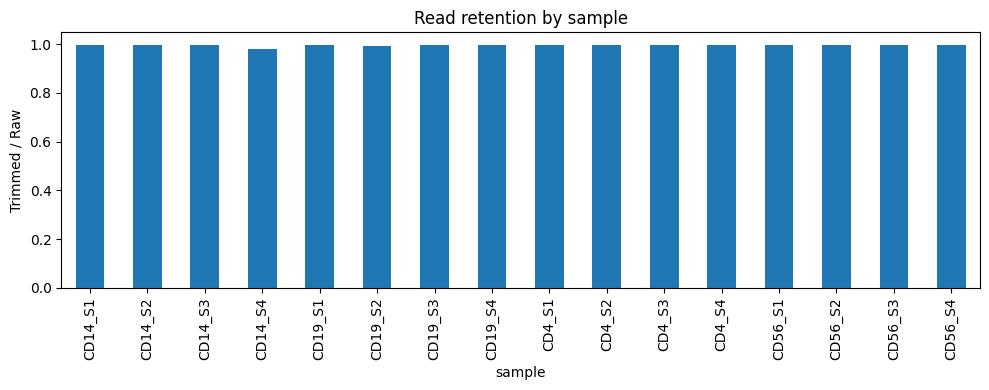

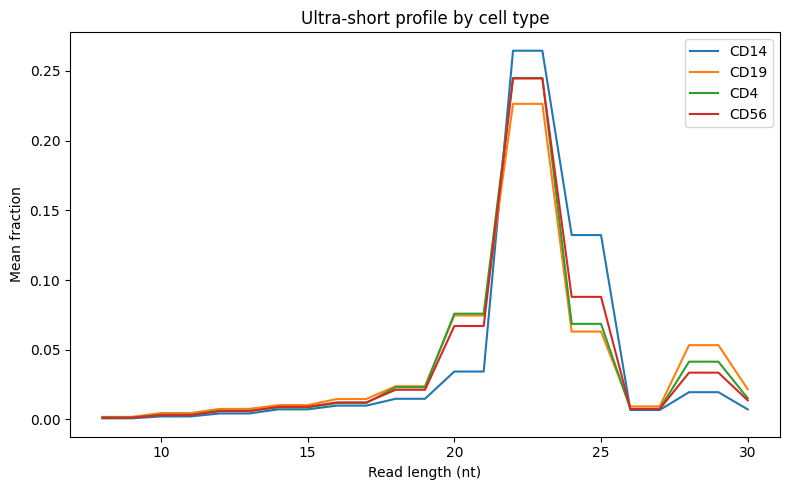

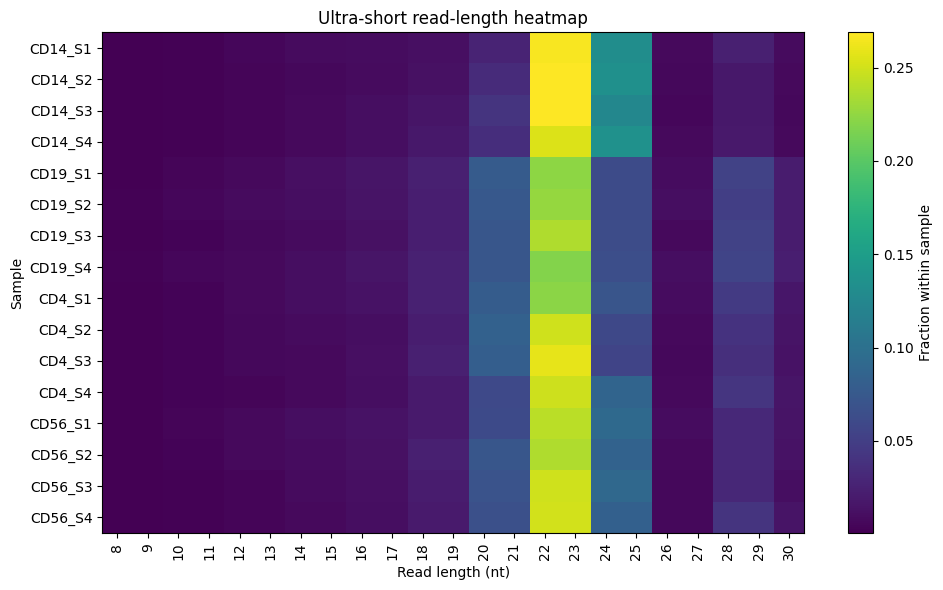

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) retained fraction
m2 = m.copy()
m2["celltype"] = m2["sample"].str.extract(r'^(CD\d+)')
m2.plot(x="sample", y="retained", kind="bar", figsize=(10,4), legend=False)
plt.ylabel("Trimmed / Raw")
plt.title("Read retention by sample")
plt.tight_layout()
plt.show()

# 2) cell-type averaged ultra-short profile
ct = trim_len[(trim_len["length"] >= 8) & (trim_len["length"] <= 30)].copy()
ct["celltype"] = ct["sample"].str.extract(r'^(CD\d+)')
ct["frac"] = ct.groupby("sample")["count"].transform(lambda x: x / x.sum())
ct_avg = ct.groupby(["celltype","length"], as_index=False)["frac"].mean()

plt.figure(figsize=(8,5))
for c, df in ct_avg.groupby("celltype"):
    plt.plot(df["length"], df["frac"], label=c)
plt.xlabel("Read length (nt)")
plt.ylabel("Mean fraction")
plt.title("Ultra-short profile by cell type")
plt.legend()
plt.tight_layout()
plt.show()

# 3) sample x length heatmap
hm = ct.pivot_table(index="sample", columns="length", values="frac", fill_value=0)
plt.figure(figsize=(10,6))
plt.imshow(hm, aspect="auto")
plt.yticks(range(len(hm.index)), hm.index)
plt.xticks(range(len(hm.columns)), hm.columns, rotation=90)
plt.colorbar(label="Fraction within sample")
plt.xlabel("Read length (nt)")
plt.ylabel("Sample")
plt.title("Ultra-short read-length heatmap")
plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path
import pandas as pd

R = Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq")

tabs = []
for sub in ["mirtrace","mirna_quant","pipeline_info","fastp","fastqc"]:
    p = R / sub
    if p.exists():
        for f in p.rglob("*"):
            if f.is_file() and f.suffix.lower() in [".txt",".tsv",".csv"]:
                tabs.append({"subdir": sub, "file": str(f.relative_to(R)), "size_kb": round(f.stat().st_size/1024,2)})

tabs = pd.DataFrame(tabs).sort_values(["subdir","file"])
tabs

,subdir,file,size_kb
103,mirtrace,mirtrace/CD14_S1/mirtrace-stats-contamination_...,0.18
98,mirtrace,mirtrace/CD14_S1/mirtrace-stats-contamination_...,4.50
100,mirtrace,mirtrace/CD14_S1/mirtrace-stats-length.tsv,0.47
102,mirtrace,mirtrace/CD14_S1/mirtrace-stats-mirna-complexi...,10.93
101,mirtrace,mirtrace/CD14_S1/mirtrace-stats-phred.tsv,0.24
...,...,...,...
115,pipeline_info,pipeline_info/execution_trace_2026-04-15_16-47...,18.20
117,pipeline_info,pipeline_info/execution_trace_2026-04-16_17-36...,15.78
113,pipeline_info,pipeline_info/execution_trace_2026-04-16_18-02...,15.93
118,pipeline_info,pipeline_info/execution_trace_2026-04-16_22-04...,15.93


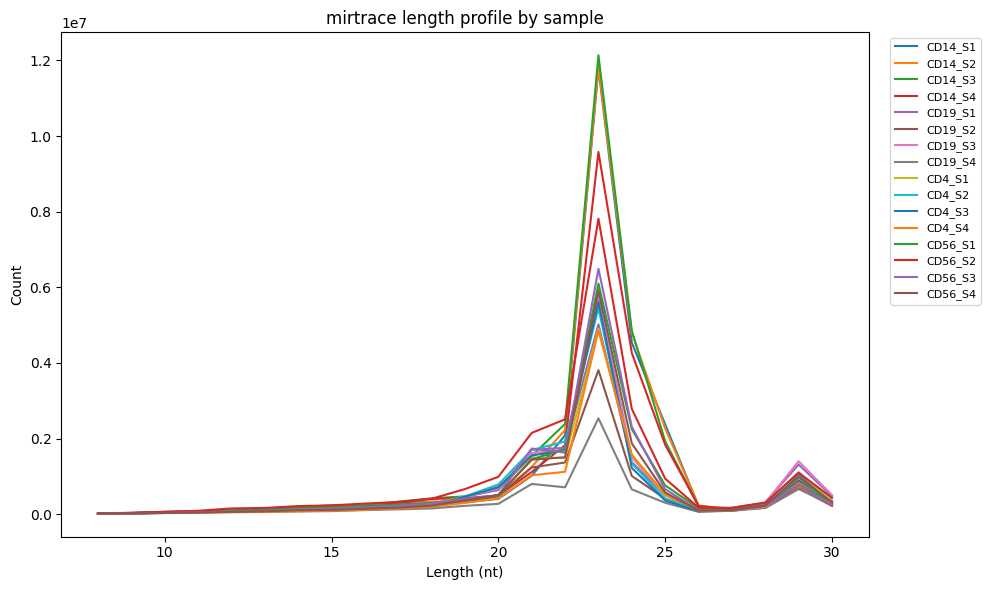

In [13]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt

R = Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirtrace")
dfs = []
for f in R.glob("*/mirtrace-stats-length.tsv"):
    s = f.parent.name
    df = pd.read_csv(f, sep="\t")
    df.columns = [c.lower().replace(" ", "_") for c in df.columns]
    xcol = [c for c in df.columns if "length" in c][0]
    ycol = [c for c in df.columns if c != xcol][0]
    df = df.rename(columns={xcol:"length", ycol:"count"})
    df["sample"] = s
    dfs.append(df)

mlen = pd.concat(dfs, ignore_index=True)
mlen = mlen[(mlen["length"] >= 8) & (mlen["length"] <= 30)]

plt.figure(figsize=(10,6))
for s, d in mlen.groupby("sample"):
    plt.plot(d["length"], d["count"], label=s)
plt.xlabel("Length (nt)"); plt.ylabel("Count")
plt.title("mirtrace length profile by sample")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

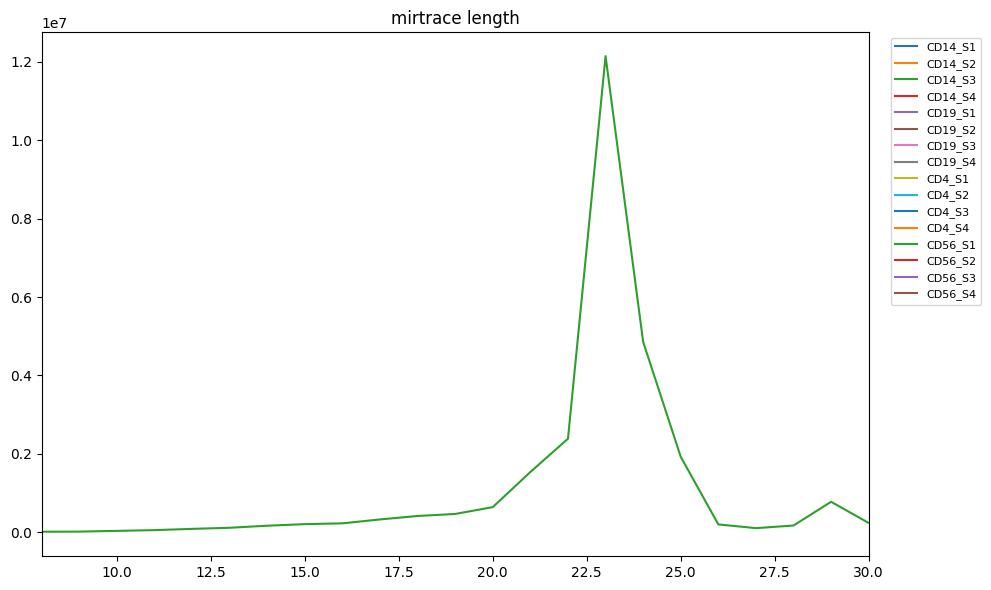

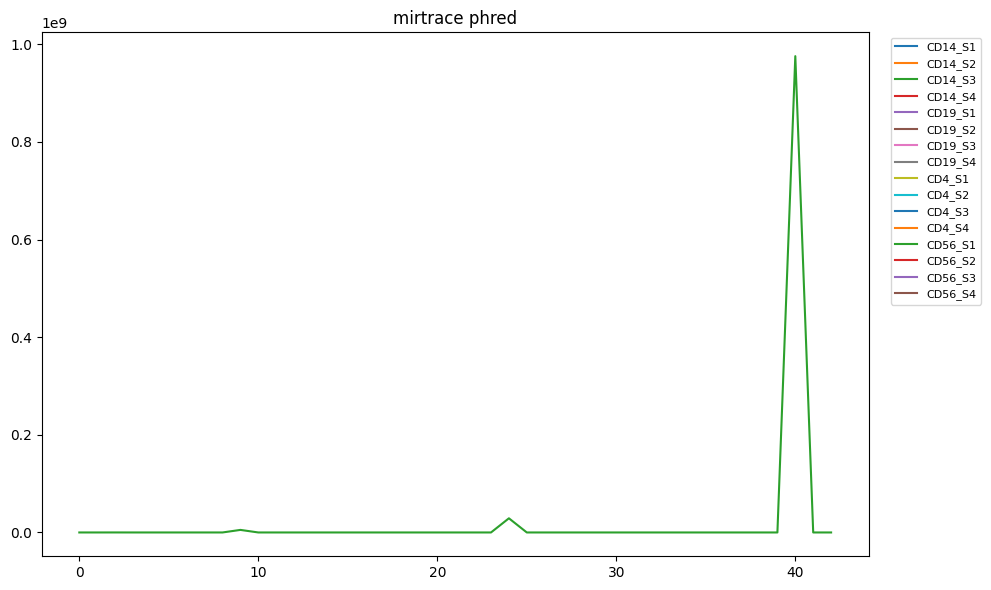

,distinct_mirna_hairpins_accumulated_count,cd14_s3,sample,cd19_s2,cd14_s4,cd56_s1,cd4_s4,cd19_s1,cd4_s3,cd56_s2,cd4_s1,cd19_s3,cd14_s2,cd19_s4,cd4_s2,cd56_s3,cd14_s1,cd56_s4
0,0,0.0,CD14_S3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0.0,CD14_S3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1.0,CD14_S3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2.0,CD14_S3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2.0,CD14_S3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,sample,file
29,CD14_S1,mirtrace-stats-contamination_basic.tsv
28,CD14_S1,mirtrace-stats-contamination_detailed.tsv
21,CD14_S2,mirtrace-stats-contamination_basic.tsv
20,CD14_S2,mirtrace-stats-contamination_detailed.tsv
1,CD14_S3,mirtrace-stats-contamination_basic.tsv
0,CD14_S3,mirtrace-stats-contamination_detailed.tsv
5,CD14_S4,mirtrace-stats-contamination_basic.tsv
4,CD14_S4,mirtrace-stats-contamination_detailed.tsv
11,CD19_S1,mirtrace-stats-contamination_basic.tsv
10,CD19_S1,mirtrace-stats-contamination_detailed.tsv


In [15]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt

R = Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirtrace")

def load_one_per_sample(pattern):
    dfs=[]
    for f in R.glob(pattern):
        s=f.parent.name
        df=pd.read_csv(f, sep="\t")
        df.columns=[c.lower().replace(" ","_") for c in df.columns]
        df["sample"]=s
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# 1) length
L=load_one_per_sample("*/mirtrace-stats-length.tsv")
x=[c for c in L.columns if "length" in c][0]
y=[c for c in L.columns if c not in [x,"sample"]][0]
plt.figure(figsize=(10,6))
for s,d in L.groupby("sample"): plt.plot(d[x], d[y], label=s)
plt.xlim(8,30); plt.title("mirtrace length"); plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

# 2) phred
P=load_one_per_sample("*/mirtrace-stats-phred.tsv")
x=[c for c in P.columns if "phred" in c or "score" in c or "position" in c][0]
y=[c for c in P.columns if c not in [x,"sample"]][0]
plt.figure(figsize=(10,6))
for s,d in P.groupby("sample"): plt.plot(d[x], d[y], label=s)
plt.title("mirtrace phred"); plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

# 3) complexity
C=load_one_per_sample("*/mirtrace-stats-mirna-complexity.tsv")
display(C.head())

# 4) contamination files inventory first
contam=[]
for f in R.glob("*/mirtrace-stats-contamination*"):
    contam.append({"sample":f.parent.name,"file":f.name})
pd.DataFrame(contam).sort_values(["sample","file"])

In [16]:
from pathlib import Path
import pandas as pd

R = Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirtrace")

f = next(R.glob("*/mirtrace-stats-contamination_basic.tsv"))
basic = pd.read_csv(f, sep="\t")
print(f.name)
print(basic.head())
print(basic.columns)

f2 = next(R.glob("*/mirtrace-stats-contamination_detailed.tsv"))
detailed = pd.read_csv(f2, sep="\t")
print(f2.name)
print(detailed.head())
print(detailed.columns)

mirtrace-stats-contamination_basic.tsv
         CLADE  CD14_S3
0   bryophytes        0
1     lycopods        0
2  gymnosperms        0
3     monocots        0
4       dicots        0
Index(['CLADE', 'CD14_S3'], dtype='object')
mirtrace-stats-contamination_detailed.tsv
      CLADE  FAMILY_ID                 MIRBASE_IDS                   SEQ  \
0  primates        548  hsa-miR-548aa,hsa-miR-548t  AAAAACCACAATTACTTTTG   
1  primates        548                mml-miR-548j  AAAAACCGCAATTACTTTTG   
2  primates        548                hsa-miR-548e  AAAAACTGAGACTACTTTTG   
3  primates        548               hsa-miR-548az  AAAAACTGCAATCACTTTTG   
4  primates        548   ggo-miR-548e,ptr-miR-548e  AAAAACTGCGACTACTTTTG   

   CD14_S3  
0        4  
1        2  
2     2470  
3        1  
4        1  
Index(['CLADE', 'FAMILY_ID', 'MIRBASE_IDS', 'SEQ', 'CD14_S3'], dtype='object')


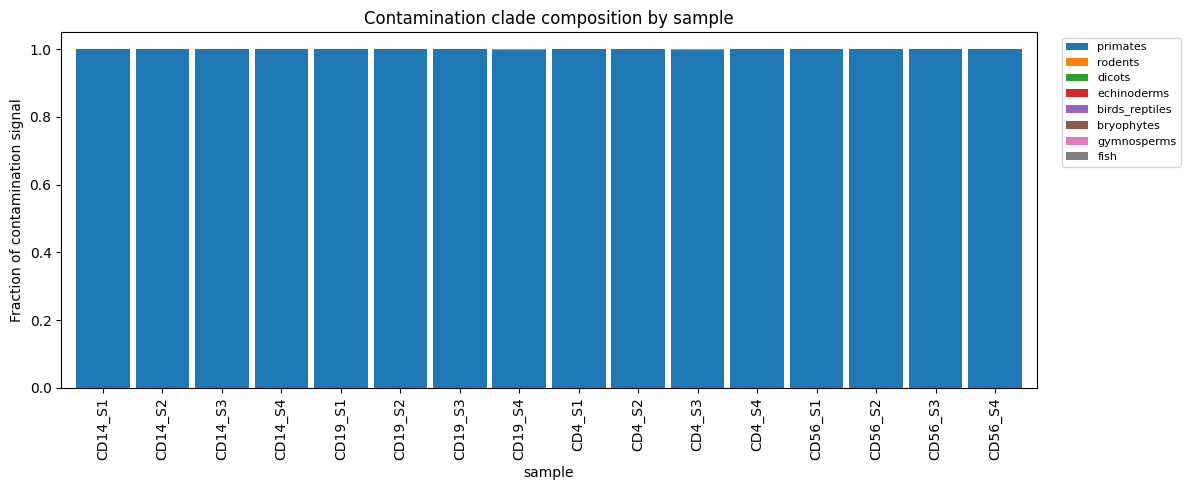

In [19]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt

R = Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirtrace")

dfs = []
for f in R.glob("*/mirtrace-stats-contamination_basic.tsv"):
    s = f.parent.name
    df = pd.read_csv(f, sep="\t")
    df.columns = ["clade", "count"]
    df["sample"] = s
    dfs.append(df)

cb = pd.concat(dfs, ignore_index=True)
mat = cb.pivot_table(index="sample", columns="clade", values="count", fill_value=0)

# keep top clades only
top = mat.sum(axis=0).sort_values(ascending=False).head(8).index
mat = mat[top]
mat = mat.div(mat.sum(axis=1), axis=0)

mat.plot(kind="bar", stacked=True, figsize=(12,5), width=0.9)
plt.ylabel("Fraction of contamination signal")
plt.title("Contamination clade composition by sample")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path("/samurlab1/Joshua/smallRNA_USRF")
RUN_DIR = PROJECT_DIR / "01.nfcore_smrnaseq"
LAUNCH_DIR = PROJECT_DIR / "launch"
LOG_DIR = PROJECT_DIR / "logs"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("PROJECT_DIR:", PROJECT_DIR)
print("RUN_DIR:", RUN_DIR)
print("LAUNCH_DIR:", LAUNCH_DIR)
print("LOG_DIR:", LOG_DIR)

def find_files(patterns, root=RUN_DIR):
    hits = []
    for pat in patterns:
        hits.extend(root.rglob(pat))
    return sorted(set(hits))

sample_sheet = LAUNCH_DIR / "sample_index.smrnaseq.single_end.csv"
if sample_sheet.exists():
    samples = pd.read_csv(sample_sheet)
    print(f"\nSamples detected: {samples['sample'].nunique() if 'sample' in samples.columns else len(samples)}")
    display(samples.head())
else:
    print("\nSample sheet not found:", sample_sheet)

miRNA_count_files = find_files(["*count*.tsv", "*count*.txt", "*counts*.csv", "*counts*.tsv"])
mirtop_files = find_files(["*mirtop*", "*isomir*", "*.gff"])
seqcluster_files = find_files(["*seqcluster*", "*cluster*.tsv", "*cluster*.txt"])
edger_files = find_files(["*edger*", "*qc*.tsv", "*qc*.csv"])
merge_files = find_files(["*merge*.tsv", "*merge*.csv", "*merged*.tsv", "*merged*.csv"])

print("\nmiRNA count files:")
for x in miRNA_count_files[:20]:
    print(x)

print("\nmiRTop files:")
for x in mirtop_files[:20]:
    print(x)

print("\nseqcluster files:")
for x in seqcluster_files[:20]:
    print(x)

print("\nedgeR/QC files:")
for x in edger_files[:20]:
    print(x)

print("\nmerged table files:")
for x in merge_files[:20]:
    print(x)

PROJECT_DIR: /samurlab1/Joshua/smallRNA_USRF
RUN_DIR: /samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq
LAUNCH_DIR: /samurlab1/Joshua/smallRNA_USRF/launch
LOG_DIR: /samurlab1/Joshua/smallRNA_USRF/logs

Samples detected: 16


,sample,fastq_1
0,CD4_S1,/samurlab1/Joshua/smallRNA_USRF/00.rawdata/CD4...
1,CD4_S2,/samurlab1/Joshua/smallRNA_USRF/00.rawdata/CD4...
2,CD4_S3,/samurlab1/Joshua/smallRNA_USRF/00.rawdata/CD4...
3,CD4_S4,/samurlab1/Joshua/smallRNA_USRF/00.rawdata/CD4...
4,CD14_S1,/samurlab1/Joshua/smallRNA_USRF/00.rawdata/CD1...



miRNA count files:
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/edger_qc/hairpin_counts.csv
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/edger_qc/hairpin_unmapped_read_counts.txt
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/edger_qc/mature_counts.csv
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/edger_qc/mature_unmapped_read_counts.txt

miRTop files:
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/mirtop
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/mirtop/export/CD14_S1_mirtop_rawData.tsv
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/mirtop/export/CD14_S2_mirtop_rawData.tsv
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/mirtop/export/CD14_S3_mirtop_rawData.tsv
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/mirtop/export/CD14_S4_mirtop_rawData.tsv
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/mirtop/export/CD19_S1_mirt

In [2]:
# ===== CHUNK 2: CORE SUMMARY METRICS =====

counts_path = RUN_DIR / "mirna_quant/edger_qc/mature_counts.csv"

counts = pd.read_csv(counts_path)

print("Counts shape:", counts.shape)
display(counts.head())

# Separate metadata vs numeric
numeric = counts.select_dtypes(include=[np.number])

# Total reads per sample
sample_totals = numeric.sum(axis=0).sort_values(ascending=False)

print("\nTotal miRNA counts per sample:")
display(sample_totals.to_frame("total_counts"))

# Number of detected miRNAs per sample
detected = (numeric > 0).sum(axis=0).sort_values(ascending=False)

print("\nDetected miRNAs per sample:")
display(detected.to_frame("n_detected"))

# Top miRNAs overall
top_mirnas = numeric.sum(axis=1).sort_values(ascending=False).head(20)

print("\nTop 20 miRNAs:")
display(top_mirnas.to_frame("total_counts"))

Counts shape: (16, 2657)


,Unnamed: 0,hsa-let-7a-5p,hsa-let-7a-3p,hsa-let-7a-2-3p,hsa-let-7b-5p,hsa-let-7b-3p,hsa-let-7c-5p,hsa-let-7c-3p,hsa-let-7d-5p,hsa-let-7d-3p,hsa-let-7e-5p,hsa-let-7e-3p,hsa-let-7f-5p,hsa-let-7f-1-3p,hsa-let-7f-2-3p,hsa-miR-15a-5p,hsa-miR-15a-3p,hsa-miR-16-5p,hsa-miR-16-1-3p,hsa-miR-17-5p,hsa-miR-17-3p,hsa-miR-18a-5p,hsa-miR-18a-3p,hsa-miR-19a-5p,hsa-miR-19a-3p,hsa-miR-19b-1-5p,hsa-miR-19b-3p,hsa-miR-19b-2-5p,hsa-miR-20a-5p,hsa-miR-20a-3p,hsa-miR-21-5p,hsa-miR-21-3p,hsa-miR-22-5p,hsa-miR-22-3p,hsa-miR-23a-5p,hsa-miR-23a-3p,hsa-miR-24-1-5p,hsa-miR-24-3p,hsa-miR-24-2-5p,hsa-miR-25-5p,hsa-miR-25-3p,hsa-miR-26a-5p,hsa-miR-26a-1-3p,hsa-miR-26b-5p,hsa-miR-26b-3p,hsa-miR-27a-5p,hsa-miR-27a-3p,hsa-miR-28-5p,hsa-miR-28-3p,hsa-miR-29a-5p,hsa-miR-29a-3p,hsa-miR-30a-5p,hsa-miR-30a-3p,hsa-miR-31-5p,hsa-miR-31-3p,hsa-miR-32-5p,hsa-miR-32-3p,hsa-miR-33a-5p,hsa-miR-33a-3p,hsa-miR-92a-1-5p,hsa-miR-92a-3p,hsa-miR-92a-2-5p,hsa-miR-93-5p,hsa-miR-93-3p,hsa-miR-95-5p,hsa-miR-95-3p,hsa-miR-96-5p,hsa-miR-96-3p,hsa-miR-98-5p,hsa-miR-98-3p,hsa-miR-99a-5p,hsa-miR-99a-3p,hsa-miR-100-5p,hsa-miR-100-3p,hsa-miR-101-5p,hsa-miR-101-3p,hsa-miR-29b-1-5p,hsa-miR-29b-3p,hsa-miR-29b-2-5p,hsa-miR-103a-2-5p,hsa-miR-103a-3p,hsa-miR-103a-1-5p,hsa-miR-105-5p,hsa-miR-105-3p,hsa-miR-106a-5p,hsa-miR-106a-3p,hsa-miR-107,hsa-miR-16-2-3p,hsa-miR-192-5p,hsa-miR-192-3p,hsa-miR-196a-5p,hsa-miR-196a-1-3p,hsa-miR-197-5p,hsa-miR-197-3p,hsa-miR-198,hsa-miR-199a-5p,hsa-miR-199a-3p,hsa-miR-208a-5p,hsa-miR-208a-3p,hsa-miR-129-5p,...,hsa-miR-8071,hsa-miR-8072,hsa-miR-8073,hsa-miR-8074,hsa-miR-8075,hsa-miR-8076,hsa-miR-8077,hsa-miR-8078,hsa-miR-8079,hsa-miR-8080,hsa-miR-8081,hsa-miR-8082,hsa-miR-8083,hsa-miR-8084,hsa-miR-8085,hsa-miR-8086,hsa-miR-8087,hsa-miR-8088,hsa-miR-8089,hsa-miR-8485,hsa-miR-9500,hsa-miR-548bb-5p,hsa-miR-548bb-3p,hsa-miR-9718,hsa-miR-9898,hsa-miR-9899,hsa-miR-9900,hsa-miR-9901,hsa-miR-9902,hsa-miR-9903,hsa-miR-9985,hsa-miR-1843,hsa-miR-548bc,hsa-miR-9986,hsa-miR-10226,hsa-miR-10392-5p,hsa-miR-10392-3p,hsa-miR-10393-5p,hsa-miR-10393-3p,hsa-miR-10394-5p,hsa-miR-10394-3p,hsa-miR-10395-5p,hsa-miR-10395-3p,hsa-miR-10396a-5p,hsa-miR-10396a-3p,hsa-miR-10397-5p,hsa-miR-10397-3p,hsa-miR-10398-5p,hsa-miR-10398-3p,hsa-miR-10399-5p,hsa-miR-10399-3p,hsa-miR-10400-5p,hsa-miR-10400-3p,hsa-miR-10401-5p,hsa-miR-10401-3p,hsa-miR-10396b-5p,hsa-miR-10396b-3p,hsa-miR-10522-5p,hsa-miR-10523-5p,hsa-miR-9983-3p,hsa-miR-10524-5p,hsa-miR-10525-3p,hsa-miR-10526-3p,hsa-miR-10527-5p,hsa-miR-11181-5p,hsa-miR-11181-3p,hsa-miR-11399,hsa-miR-11400,hsa-miR-11401,hsa-miR-3059-5p,hsa-miR-3059-3p,hsa-miR-3085-5p,hsa-miR-3085-3p,hsa-miR-6529-5p,hsa-miR-6529-3p,hsa-miR-9851-5p,hsa-miR-9851-3p,hsa-miR-12113,hsa-miR-12114,hsa-miR-12115,hsa-miR-12116,hsa-miR-12117,hsa-miR-12118,hsa-miR-12119,hsa-miR-12120,hsa-miR-12121,hsa-miR-12122,hsa-miR-12123,hsa-miR-12124,hsa-miR-12125,hsa-miR-12126,hsa-miR-12127,hsa-miR-12128,hsa-miR-12129,hsa-miR-12130,hsa-miR-12131,hsa-miR-12132,hsa-miR-12133,hsa-miR-12135,hsa-miR-12136
0,CD14_S3,66527,270,191,23700,104,2386,99,9679,196,267,281,66774,92,162,5018,281,11624,339,962,316,293,217,260,135,63,181,50,713,381,168137,98,658,12349,457,1858,191,20859,2886,465,11820,16807,67,5967,131,917,12296,216,14294,168,13918,368,185,128,115,1673,837,126,336,167,2435,99,3768,230,190,428,165,229,3010,64,627,35,502,42,196,164969,409,919,137,185,59731,187,441,99,277,84,7265,1032,2966,1864,40,107,413,371,2019,305,20791,1175,68,153,...,297,755,273,297,180,597,330,467,161,175,714,734,274,57,425,436,95,283,689,57,142,32,24,297,474,1105,148,616,83,311,2784,187,299,157,1573,519,910,231,175,393,1349,295,93,2240,602,153,810,493,660,378,317,1168,2853,253,1997,2346,694,180,1977,254,72,68,806,291,373,240,1364,58,497,422,118,529,358,253,83,300,207,175,605,993,1049,154,802,554,599,484,667,426,63,130,935,3038,486,157,97,93,642,166,328,72
1,CD19_S3,176868,692,131,20503,93,3135,27,17010,395,483,106,213024,78,280,3209,131,12037,680,467,237,89,69,294,101,56,154,44,440,507,220548,65,463,4319,178,1435,149,4395,546


Total miRNA counts per sample:


,total_counts
hsa-miR-21-5p,4281645
hsa-miR-146b-5p,4074918
hsa-let-7g-5p,2615739
hsa-miR-101-3p,2084330
hsa-let-7f-5p,1777911
...,...
hsa-miR-548ap-3p,216
hsa-miR-1185-5p,203
hsa-miR-521,202
hsa-miR-4310,192



Detected miRNAs per sample:


,n_detected
hsa-miR-10524-5p,16
hsa-miR-10525-3p,16
hsa-miR-10526-3p,16
hsa-miR-10527-5p,16
hsa-miR-11181-5p,16
...,...
hsa-let-7b-5p,16
hsa-let-7b-3p,16
hsa-let-7c-5p,16
hsa-let-7c-3p,16



Top 20 miRNAs:


,total_counts
2,5532188
9,4022410
11,3653749
7,3649481
5,3606814
4,3495825
1,3399055
14,3124654
8,3069638
0,2971938


In [3]:
# ===== CHUNK 2: CORE SUMMARY METRICS =====

counts_path = RUN_DIR / "mirna_quant/edger_qc/mature_counts.csv"

counts = pd.read_csv(counts_path)

print("Counts shape:", counts.shape)
display(counts.head())

# Numeric sample columns only
numeric = counts.select_dtypes(include=[np.number])

# Total miRNA counts per sample
sample_totals = numeric.sum(axis=0).sort_values(ascending=False)
print("\nTotal miRNA counts per sample:")
display(sample_totals.to_frame("total_counts"))

# Number of detected miRNAs per sample
detected = (numeric > 0).sum(axis=0).sort_values(ascending=False)
print("\nDetected miRNAs per sample:")
display(detected.to_frame("n_detected"))

# Identify miRNA name column if present
name_col = None
for col in counts.columns:
    if str(col).lower() in ["mirna", "mature", "name", "id", "gene"]:
        name_col = col
        break

# Top miRNAs overall
row_sums = numeric.sum(axis=1)
top_idx = row_sums.sort_values(ascending=False).head(20).index

if name_col is not None:
    top_mirnas = counts.loc[top_idx, [name_col]].copy()
    top_mirnas["total_counts"] = row_sums.loc[top_idx].values
else:
    top_mirnas = pd.DataFrame({
        "row_index": top_idx,
        "total_counts": row_sums.loc[top_idx].values
    })

print("\nTop 20 miRNAs overall:")
display(top_mirnas)

Counts shape: (16, 2657)


,Unnamed: 0,hsa-let-7a-5p,hsa-let-7a-3p,hsa-let-7a-2-3p,hsa-let-7b-5p,hsa-let-7b-3p,hsa-let-7c-5p,hsa-let-7c-3p,hsa-let-7d-5p,hsa-let-7d-3p,hsa-let-7e-5p,hsa-let-7e-3p,hsa-let-7f-5p,hsa-let-7f-1-3p,hsa-let-7f-2-3p,hsa-miR-15a-5p,hsa-miR-15a-3p,hsa-miR-16-5p,hsa-miR-16-1-3p,hsa-miR-17-5p,hsa-miR-17-3p,hsa-miR-18a-5p,hsa-miR-18a-3p,hsa-miR-19a-5p,hsa-miR-19a-3p,hsa-miR-19b-1-5p,hsa-miR-19b-3p,hsa-miR-19b-2-5p,hsa-miR-20a-5p,hsa-miR-20a-3p,hsa-miR-21-5p,hsa-miR-21-3p,hsa-miR-22-5p,hsa-miR-22-3p,hsa-miR-23a-5p,hsa-miR-23a-3p,hsa-miR-24-1-5p,hsa-miR-24-3p,hsa-miR-24-2-5p,hsa-miR-25-5p,hsa-miR-25-3p,hsa-miR-26a-5p,hsa-miR-26a-1-3p,hsa-miR-26b-5p,hsa-miR-26b-3p,hsa-miR-27a-5p,hsa-miR-27a-3p,hsa-miR-28-5p,hsa-miR-28-3p,hsa-miR-29a-5p,hsa-miR-29a-3p,hsa-miR-30a-5p,hsa-miR-30a-3p,hsa-miR-31-5p,hsa-miR-31-3p,hsa-miR-32-5p,hsa-miR-32-3p,hsa-miR-33a-5p,hsa-miR-33a-3p,hsa-miR-92a-1-5p,hsa-miR-92a-3p,hsa-miR-92a-2-5p,hsa-miR-93-5p,hsa-miR-93-3p,hsa-miR-95-5p,hsa-miR-95-3p,hsa-miR-96-5p,hsa-miR-96-3p,hsa-miR-98-5p,hsa-miR-98-3p,hsa-miR-99a-5p,hsa-miR-99a-3p,hsa-miR-100-5p,hsa-miR-100-3p,hsa-miR-101-5p,hsa-miR-101-3p,hsa-miR-29b-1-5p,hsa-miR-29b-3p,hsa-miR-29b-2-5p,hsa-miR-103a-2-5p,hsa-miR-103a-3p,hsa-miR-103a-1-5p,hsa-miR-105-5p,hsa-miR-105-3p,hsa-miR-106a-5p,hsa-miR-106a-3p,hsa-miR-107,hsa-miR-16-2-3p,hsa-miR-192-5p,hsa-miR-192-3p,hsa-miR-196a-5p,hsa-miR-196a-1-3p,hsa-miR-197-5p,hsa-miR-197-3p,hsa-miR-198,hsa-miR-199a-5p,hsa-miR-199a-3p,hsa-miR-208a-5p,hsa-miR-208a-3p,hsa-miR-129-5p,...,hsa-miR-8071,hsa-miR-8072,hsa-miR-8073,hsa-miR-8074,hsa-miR-8075,hsa-miR-8076,hsa-miR-8077,hsa-miR-8078,hsa-miR-8079,hsa-miR-8080,hsa-miR-8081,hsa-miR-8082,hsa-miR-8083,hsa-miR-8084,hsa-miR-8085,hsa-miR-8086,hsa-miR-8087,hsa-miR-8088,hsa-miR-8089,hsa-miR-8485,hsa-miR-9500,hsa-miR-548bb-5p,hsa-miR-548bb-3p,hsa-miR-9718,hsa-miR-9898,hsa-miR-9899,hsa-miR-9900,hsa-miR-9901,hsa-miR-9902,hsa-miR-9903,hsa-miR-9985,hsa-miR-1843,hsa-miR-548bc,hsa-miR-9986,hsa-miR-10226,hsa-miR-10392-5p,hsa-miR-10392-3p,hsa-miR-10393-5p,hsa-miR-10393-3p,hsa-miR-10394-5p,hsa-miR-10394-3p,hsa-miR-10395-5p,hsa-miR-10395-3p,hsa-miR-10396a-5p,hsa-miR-10396a-3p,hsa-miR-10397-5p,hsa-miR-10397-3p,hsa-miR-10398-5p,hsa-miR-10398-3p,hsa-miR-10399-5p,hsa-miR-10399-3p,hsa-miR-10400-5p,hsa-miR-10400-3p,hsa-miR-10401-5p,hsa-miR-10401-3p,hsa-miR-10396b-5p,hsa-miR-10396b-3p,hsa-miR-10522-5p,hsa-miR-10523-5p,hsa-miR-9983-3p,hsa-miR-10524-5p,hsa-miR-10525-3p,hsa-miR-10526-3p,hsa-miR-10527-5p,hsa-miR-11181-5p,hsa-miR-11181-3p,hsa-miR-11399,hsa-miR-11400,hsa-miR-11401,hsa-miR-3059-5p,hsa-miR-3059-3p,hsa-miR-3085-5p,hsa-miR-3085-3p,hsa-miR-6529-5p,hsa-miR-6529-3p,hsa-miR-9851-5p,hsa-miR-9851-3p,hsa-miR-12113,hsa-miR-12114,hsa-miR-12115,hsa-miR-12116,hsa-miR-12117,hsa-miR-12118,hsa-miR-12119,hsa-miR-12120,hsa-miR-12121,hsa-miR-12122,hsa-miR-12123,hsa-miR-12124,hsa-miR-12125,hsa-miR-12126,hsa-miR-12127,hsa-miR-12128,hsa-miR-12129,hsa-miR-12130,hsa-miR-12131,hsa-miR-12132,hsa-miR-12133,hsa-miR-12135,hsa-miR-12136
0,CD14_S3,66527,270,191,23700,104,2386,99,9679,196,267,281,66774,92,162,5018,281,11624,339,962,316,293,217,260,135,63,181,50,713,381,168137,98,658,12349,457,1858,191,20859,2886,465,11820,16807,67,5967,131,917,12296,216,14294,168,13918,368,185,128,115,1673,837,126,336,167,2435,99,3768,230,190,428,165,229,3010,64,627,35,502,42,196,164969,409,919,137,185,59731,187,441,99,277,84,7265,1032,2966,1864,40,107,413,371,2019,305,20791,1175,68,153,...,297,755,273,297,180,597,330,467,161,175,714,734,274,57,425,436,95,283,689,57,142,32,24,297,474,1105,148,616,83,311,2784,187,299,157,1573,519,910,231,175,393,1349,295,93,2240,602,153,810,493,660,378,317,1168,2853,253,1997,2346,694,180,1977,254,72,68,806,291,373,240,1364,58,497,422,118,529,358,253,83,300,207,175,605,993,1049,154,802,554,599,484,667,426,63,130,935,3038,486,157,97,93,642,166,328,72
1,CD19_S3,176868,692,131,20503,93,3135,27,17010,395,483,106,213024,78,280,3209,131,12037,680,467,237,89,69,294,101,56,154,44,440,507,220548,65,463,4319,178,1435,149,4395,546


Total miRNA counts per sample:


,total_counts
hsa-miR-21-5p,4281645
hsa-miR-146b-5p,4074918
hsa-let-7g-5p,2615739
hsa-miR-101-3p,2084330
hsa-let-7f-5p,1777911
...,...
hsa-miR-548ap-3p,216
hsa-miR-1185-5p,203
hsa-miR-521,202
hsa-miR-4310,192



Detected miRNAs per sample:


,n_detected
hsa-miR-10524-5p,16
hsa-miR-10525-3p,16
hsa-miR-10526-3p,16
hsa-miR-10527-5p,16
hsa-miR-11181-5p,16
...,...
hsa-let-7b-5p,16
hsa-let-7b-3p,16
hsa-let-7c-5p,16
hsa-let-7c-3p,16



Top 20 miRNAs overall:


,row_index,total_counts
0,2,5532188
1,9,4022410
2,11,3653749
3,7,3649481
4,5,3606814
5,4,3495825
6,1,3399055
7,14,3124654
8,8,3069638
9,0,2971938


In [4]:
# ===== CHUNK 2b: CORRECT SAMPLE-LEVEL SUMMARY =====

counts_path = RUN_DIR / "mirna_quant/edger_qc/mature_counts.csv"
counts = pd.read_csv(counts_path)

# first column is sample ID
sample_col = counts.columns[0]
sample_ids = counts[sample_col].astype(str)

# all remaining columns should be miRNAs
numeric = counts.iloc[:, 1:].apply(pd.to_numeric, errors="coerce").fillna(0)

print("Counts shape:", counts.shape)
print("Sample column:", sample_col)

# total miRNA counts per sample
sample_totals = numeric.sum(axis=1)
sample_summary = pd.DataFrame({
    "sample": sample_ids,
    "total_miRNA_counts": sample_totals,
    "n_detected_miRNAs": (numeric > 0).sum(axis=1)
}).sort_values("total_miRNA_counts", ascending=False)

print("\nSample-level summary:")
display(sample_summary)

# top miRNAs across all samples
mirna_totals = numeric.sum(axis=0).sort_values(ascending=False)
top_mirnas = mirna_totals.head(20).to_frame("total_counts").reset_index()
top_mirnas.columns = ["miRNA", "total_counts"]

print("\nTop 20 miRNAs across all samples:")
display(top_mirnas)

Counts shape: (16, 2657)
Sample column: Unnamed: 0

Sample-level summary:


,sample,total_miRNA_counts,n_detected_miRNAs
2,CD56_S2,5532188,2656
9,CD4_S2,4022410,2656
11,CD56_S1,3653749,2656
7,CD19_S1,3649481,2656
5,CD4_S1,3606814,2656
4,CD4_S3,3495825,2656
1,CD19_S3,3399055,2656
14,CD19_S2,3124654,2656
8,CD56_S3,3069638,2656
0,CD14_S3,2971938,2656



Top 20 miRNAs across all samples:


,miRNA,total_counts
0,hsa-miR-21-5p,4281645
1,hsa-miR-146b-5p,4074918
2,hsa-let-7g-5p,2615739
3,hsa-miR-101-3p,2084330
4,hsa-let-7f-5p,1777911
5,hsa-let-7a-5p,1733154
6,hsa-miR-142-5p,1649458
7,hsa-miR-191-5p,1321597
8,hsa-miR-181a-5p,1227828
9,hsa-miR-26a-5p,989135


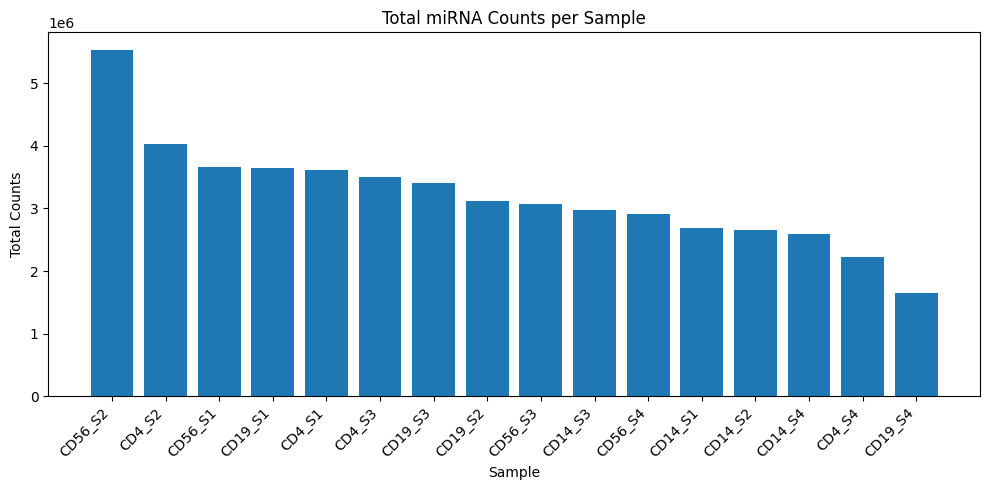

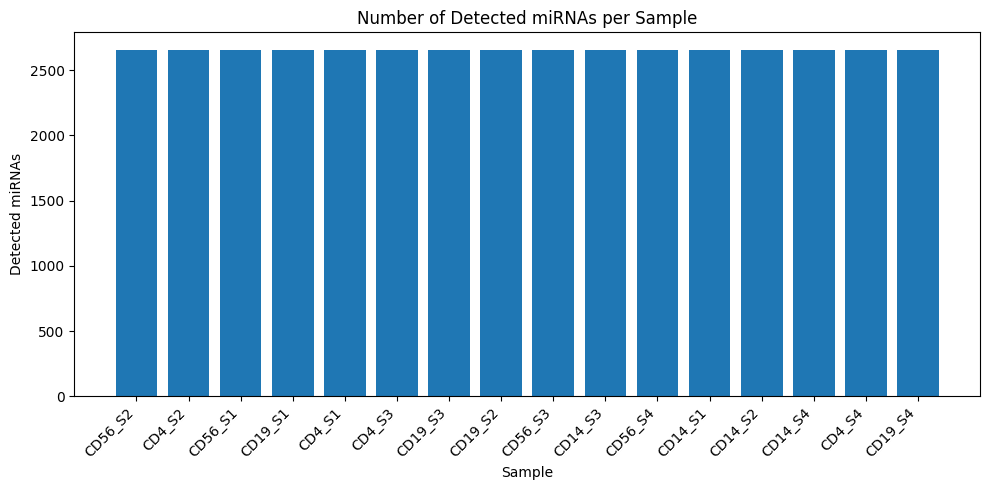

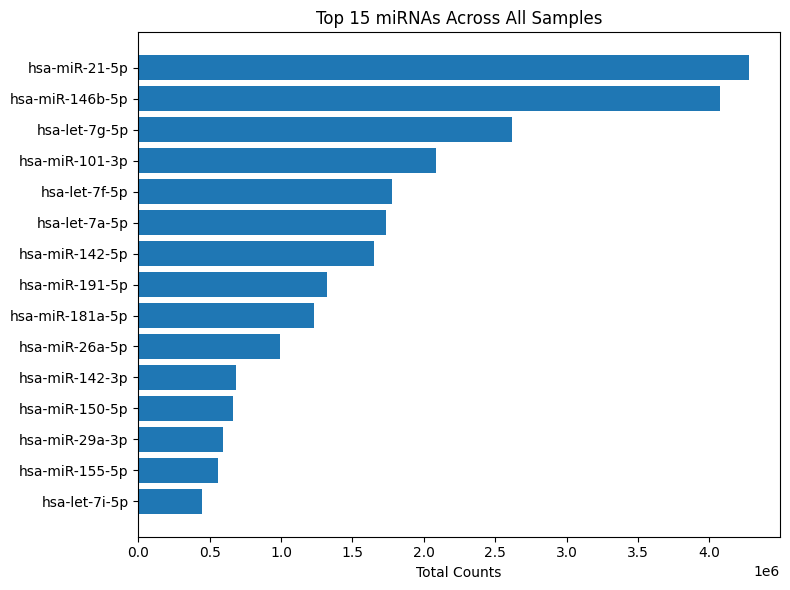

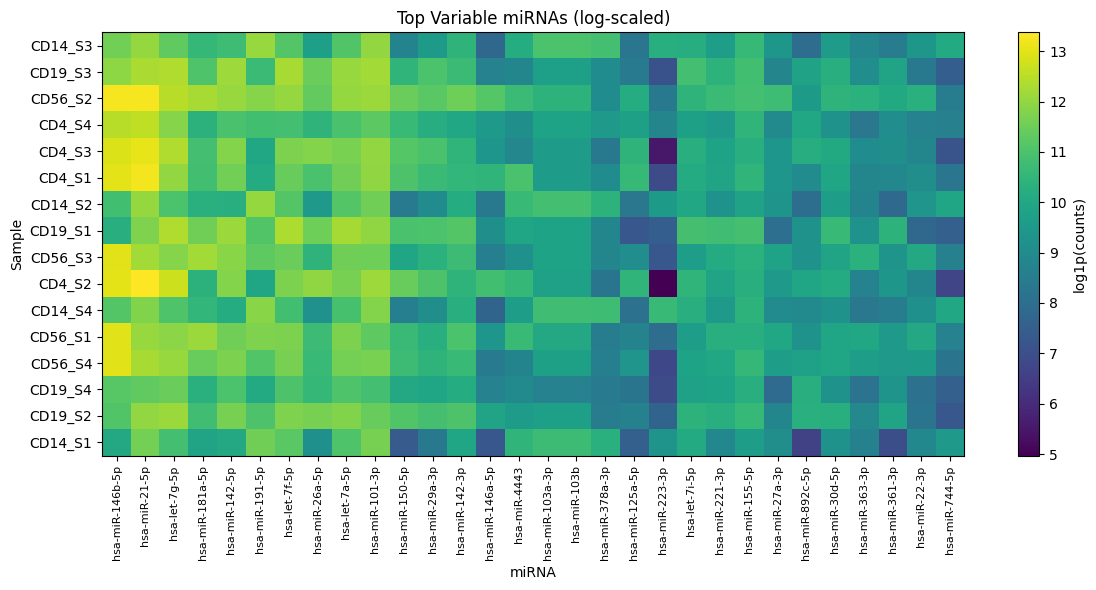

In [6]:
# ===== CHUNK 3: VISUALIZATION (matplotlib only) =====

import matplotlib.pyplot as plt
import numpy as np

# assumes these already exist from previous chunk:
# sample_summary, numeric, sample_ids, mirna_totals

# --- 1. total counts per sample ---
plt.figure(figsize=(10, 5))
plt.bar(sample_summary["sample"], sample_summary["total_miRNA_counts"])
plt.xticks(rotation=45, ha="right")
plt.title("Total miRNA Counts per Sample")
plt.ylabel("Total Counts")
plt.xlabel("Sample")
plt.tight_layout()
plt.show()


# --- 2. detected miRNAs per sample ---
plt.figure(figsize=(10, 5))
plt.bar(sample_summary["sample"], sample_summary["n_detected_miRNAs"])
plt.xticks(rotation=45, ha="right")
plt.title("Number of Detected miRNAs per Sample")
plt.ylabel("Detected miRNAs")
plt.xlabel("Sample")
plt.tight_layout()
plt.show()


# --- 3. top miRNAs barplot ---
top_mirnas_plot = mirna_totals.head(15).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(top_mirnas_plot.index, top_mirnas_plot.values)
plt.title("Top 15 miRNAs Across All Samples")
plt.xlabel("Total Counts")
plt.tight_layout()
plt.show()


# --- 4. heatmap of top variable miRNAs ---
variance = numeric.var(axis=0)
top_var = variance.sort_values(ascending=False).head(30).index

heatmap_data = np.log1p(numeric[top_var])

plt.figure(figsize=(12, 6))
im = plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(im, label="log1p(counts)")
plt.title("Top Variable miRNAs (log-scaled)")
plt.xlabel("miRNA")
plt.ylabel("Sample")
plt.xticks(
    ticks=np.arange(len(top_var)),
    labels=top_var,
    rotation=90,
    fontsize=8
)
plt.yticks(
    ticks=np.arange(len(sample_ids)),
    labels=sample_ids
)
plt.tight_layout()
plt.show()

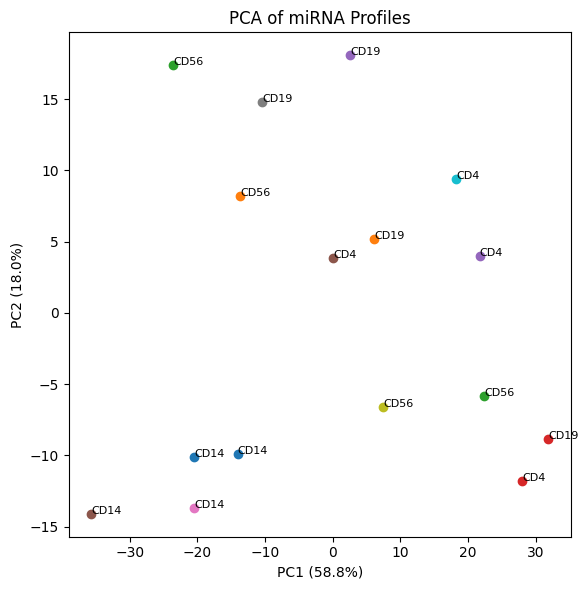

In [8]:
# ===== CHUNK 4: PCA (no sklearn) =====

import numpy as np
import matplotlib.pyplot as plt

# log transform
X = np.log1p(numeric.values)

# center data
X_centered = X - X.mean(axis=0)

# SVD for PCA
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# principal components
PCs = U[:, :2] @ np.diag(S[:2])

# variance explained
var_explained = (S**2) / np.sum(S**2)

# plot
plt.figure(figsize=(6,6))

for i, sample in enumerate(sample_ids):
    label = sample.split("_")[0]  # CD14, CD19, etc
    plt.scatter(PCs[i,0], PCs[i,1])
    plt.text(PCs[i,0], PCs[i,1], label, fontsize=8)

plt.title("PCA of miRNA Profiles")
plt.xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

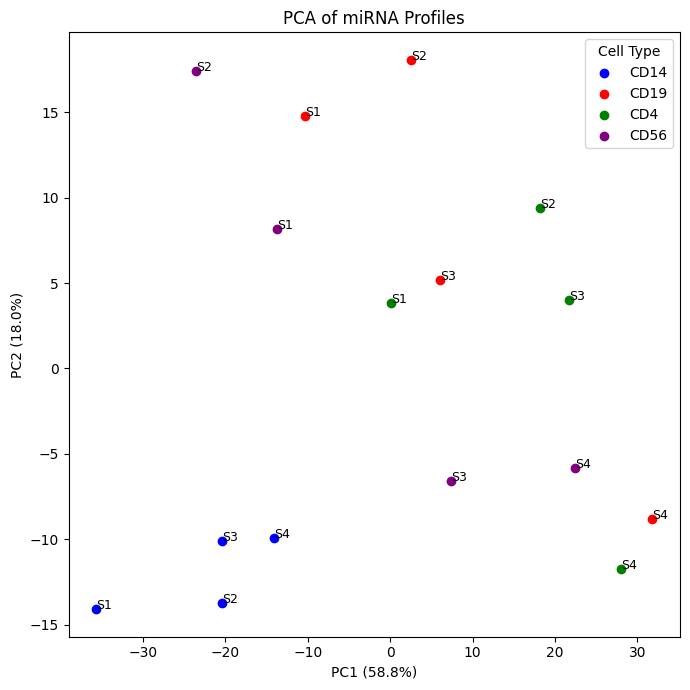

In [12]:
# ===== PCA WITH CELL TYPE COLORS + REPLICATE LABELS =====

import matplotlib.pyplot as plt
import numpy as np

# define colors per cell type
color_map = {
    "CD14": "blue",
    "CD19": "red",
    "CD4": "green",
    "CD56": "purple"
}

plt.figure(figsize=(7,7))

for i, sample in enumerate(sample_ids):
    parts = sample.split("_")
    cell_type = parts[0]
    replicate = parts[1] if len(parts) > 1 else ""

    color = color_map.get(cell_type, "black")

    plt.scatter(PCs[i,0], PCs[i,1], color=color)
    
    # label with replicate (S1–S4)
    plt.text(PCs[i,0], PCs[i,1], replicate, fontsize=9)

# legend
for ct, col in color_map.items():
    plt.scatter([], [], color=col, label=ct)
plt.legend(title="Cell Type")

plt.title("PCA of miRNA Profiles")
plt.xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

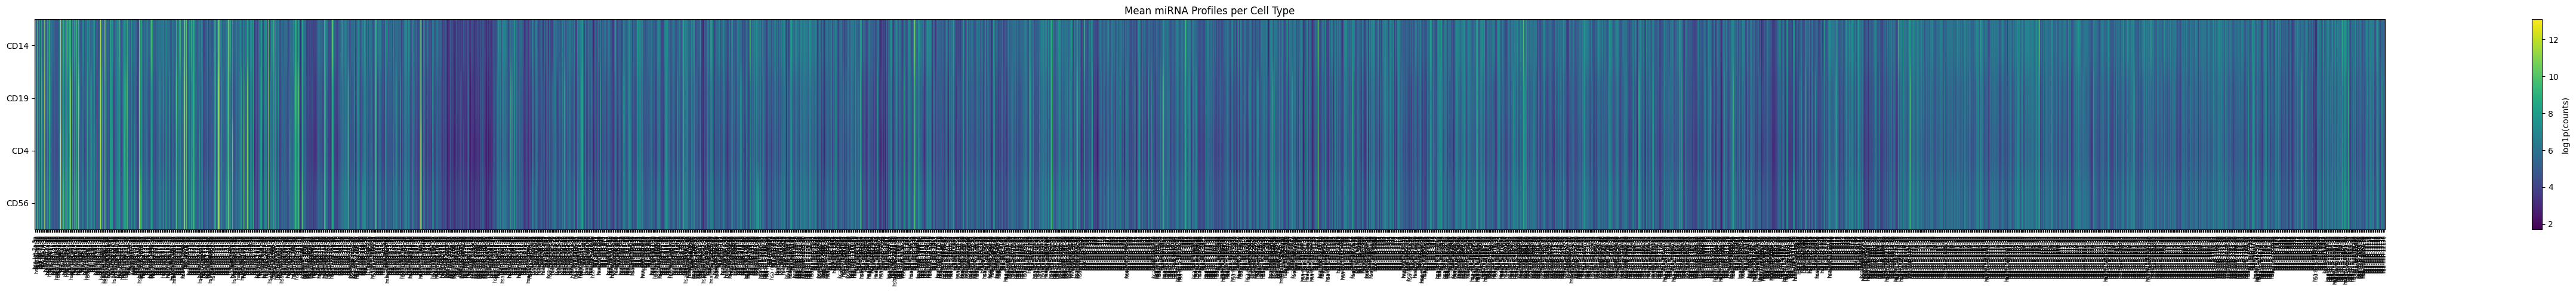

In [11]:
# extract cell type
cell_types = [s.split("_")[0] for s in sample_ids]

df = numeric.copy()
df["cell_type"] = cell_types

# mean per cell type
mean_profiles = df.groupby("cell_type").mean()

plt.figure(figsize=(50,5))
plt.imshow(np.log1p(mean_profiles), aspect="auto")
plt.colorbar(label="log1p(counts)")
plt.xticks(range(len(mean_profiles.columns)), mean_profiles.columns, rotation=90, fontsize=6)
plt.yticks(range(len(mean_profiles.index)), mean_profiles.index)
plt.title("Mean miRNA Profiles per Cell Type")
plt.tight_layout()
plt.show()

In [8]:
# ===== CHUNK 5: LOAD UNMAPPED COUNT TABLES =====

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip
from collections import Counter

unmapped_mature_path = RUN_DIR / "mirna_quant/edger_qc/mature_unmapped_read_counts.txt"
unmapped_hairpin_path = RUN_DIR / "mirna_quant/edger_qc/hairpin_unmapped_read_counts.txt"

mature_unmapped = pd.read_csv(unmapped_mature_path, sep="\t")
hairpin_unmapped = pd.read_csv(unmapped_hairpin_path, sep="\t")

print("mature_unmapped shape:", mature_unmapped.shape)
display(mature_unmapped.head())

print("hairpin_unmapped shape:", hairpin_unmapped.shape)
display(hairpin_unmapped.head())

mature_unmapped shape: (1, 16)


,CD14_S3,CD19_S3,CD56_S2,CD4_S4,CD4_S3,CD4_S1,CD14_S2,CD19_S1,CD56_S3,CD4_S2,CD14_S4,CD56_S1,CD56_S4,CD19_S4,CD19_S2,CD14_S1
*,33398554,28322560,28209310,27097673,28340205,25651042,34639415,28031331,25976721,26788393,35238363,28245059,27713503,24019234,26483412,32136797


hairpin_unmapped shape: (1, 16)


,CD14_S1,CD56_S1,CD56_S3,CD14_S3,CD56_S4,CD14_S2,CD19_S4,CD56_S2,CD19_S2,CD4_S3,CD14_S4,CD4_S4,CD4_S1,CD4_S2,CD19_S1,CD19_S3
*,11276318,17623326,14589098,11535091,17877836,13203188,19730678,14407695,19877333,19421246,17559159,19077579,17193253,17855934,19191518,18703418


In [9]:
# ===== CHUNK 6b: COMPARE MATURE vs HAIRPIN UNMAPPED =====

mature_vals = mature_unmapped.iloc[0]
hairpin_vals = hairpin_unmapped.iloc[0]

compare_df = pd.DataFrame({
    "sample": mature_vals.index,
    "mature_unmapped": mature_vals.values,
    "hairpin_unmapped": hairpin_vals.values,
})

compare_df["difference"] = compare_df["hairpin_unmapped"] - compare_df["mature_unmapped"]
compare_df["pct_change"] = 100 * compare_df["difference"] / compare_df["mature_unmapped"]

display(compare_df.sort_values("hairpin_unmapped", ascending=False))

,sample,mature_unmapped,hairpin_unmapped,difference,pct_change
8,CD56_S3,25976721,19877333,-6099388,-23.480208
6,CD14_S2,34639415,19730678,-14908737,-43.039806
9,CD4_S2,26788393,19421246,-7367147,-27.501265
14,CD19_S2,26483412,19191518,-7291894,-27.533816
11,CD56_S1,28245059,19077579,-9167480,-32.456933
15,CD14_S1,32136797,18703418,-13433379,-41.800616
4,CD4_S3,28340205,17877836,-10462369,-36.917055
13,CD19_S4,24019234,17855934,-6163300,-25.659852
1,CD19_S3,28322560,17623326,-10699234,-37.776366
10,CD14_S4,35238363,17559159,-17679204,-50.170333


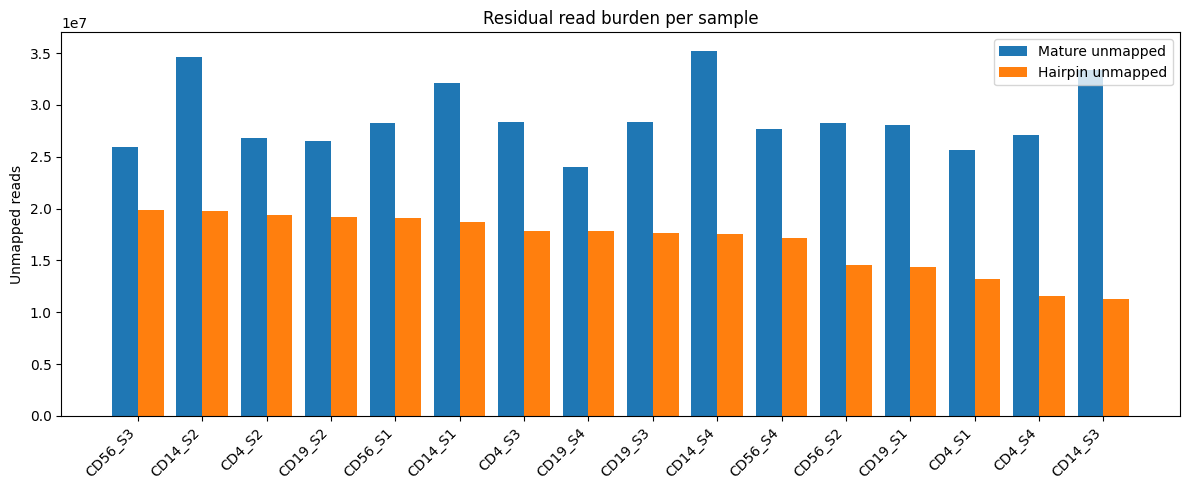

In [10]:
# ===== FIXED BARPLOT WITH LABELS =====

plot_df = compare_df.sort_values("hairpin_unmapped", ascending=False).reset_index(drop=True)

x = np.arange(len(plot_df))
w = 0.4

plt.figure(figsize=(12,5))

plt.bar(x - w/2, plot_df["mature_unmapped"], width=w, label="Mature unmapped")
plt.bar(x + w/2, plot_df["hairpin_unmapped"], width=w, label="Hairpin unmapped")

# FORCE LABELS
plt.xticks(x, plot_df["sample"], rotation=45, ha="right")

plt.ylabel("Unmapped reads")
plt.title("Residual read burden per sample")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# ===== CHUNK 6e: APPROX FRACTION UNEXPLAINED =====

mapped_mature = numeric.sum(axis=1).values

fraction_df = pd.DataFrame({
    "sample": sample_ids,
    "mapped_mature_counts": mapped_mature,
    "mature_unmapped": mature_vals.reindex(sample_ids).values,
    "hairpin_unmapped": hairpin_vals.reindex(sample_ids).values,
})

fraction_df["mature_unmapped_fraction"] = fraction_df["mature_unmapped"] / (
    fraction_df["mapped_mature_counts"] + fraction_df["mature_unmapped"]
)

fraction_df["hairpin_unmapped_fraction"] = fraction_df["hairpin_unmapped"] / (
    fraction_df["mapped_mature_counts"] + fraction_df["hairpin_unmapped"]
)

display(fraction_df)

,sample,mapped_mature_counts,mature_unmapped,hairpin_unmapped,mature_unmapped_fraction,hairpin_unmapped_fraction
0,CD14_S3,2971938,33398554,11535091,0.918287,0.795138
1,CD19_S3,3399055,28322560,18703418,0.892847,0.846214
2,CD56_S2,5532188,28209310,14407695,0.836042,0.722557
3,CD4_S4,2216467,27097673,19077579,0.924389,0.895911
4,CD4_S3,3495825,28340205,19421246,0.890193,0.847458
5,CD4_S1,3606814,25651042,17193253,0.876723,0.826596
6,CD14_S2,2662424,34639415,13203188,0.928625,0.832189
7,CD19_S1,3649481,28031331,19191518,0.884805,0.840222
8,CD56_S3,3069638,25976721,14589098,0.894319,0.826169
9,CD4_S2,4022410,26788393,17855934,0.869448,0.816147


In [3]:
# ===== BUILD seq_counts FROM seqcluster FASTQS =====

from pathlib import Path
import pandas as pd
import gzip
from collections import Counter

seqcluster_dir = RUN_DIR / "mirna_quant/seqcluster"
fastq_files = sorted(seqcluster_dir.glob("*_seqcluster.fastq.gz"))

print("FASTQ files found:", len(fastq_files))
for f in fastq_files[:5]:
    print(f)

def read_fastq_sequences_gz(path):
    seqs = []
    with gzip.open(path, "rt") as fh:
        for i, line in enumerate(fh):
            if i % 4 == 1:
                seqs.append(line.strip())
    return seqs

all_seq_tables = []

for fq in fastq_files:
    sample = fq.name.replace("_seqcluster.fastq.gz", "")
    seqs = read_fastq_sequences_gz(fq)
    counts = Counter(seqs)

    df = pd.DataFrame({
        "sequence": list(counts.keys()),
        "count": list(counts.values())
    })
    df["sample"] = sample
    df["cell_type"] = sample.split("_")[0]
    df["length"] = df["sequence"].str.len()

    all_seq_tables.append(df)

seq_counts = pd.concat(all_seq_tables, ignore_index=True)

print("seq_counts shape:", seq_counts.shape)
display(seq_counts.head())

FASTQ files found: 16
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/seqcluster/CD14_S1_seqcluster.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/seqcluster/CD14_S2_seqcluster.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/seqcluster/CD14_S3_seqcluster.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/seqcluster/CD14_S4_seqcluster.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/mirna_quant/seqcluster/CD19_S1_seqcluster.fastq.gz
seq_counts shape: (20785810, 5)


,sequence,count,sample,cell_type,length
0,TTCAAGTAATCCAGGATAGGCTA,1,CD14_S1,CD14,23
1,TGAGGTAGTAGTTTGTGCTGTTA,1,CD14_S1,CD14,23
2,AGCTTATCAGACTGATGTTGAA,1,CD14_S1,CD14,22
3,CAACGGAATCCCAAAAGCAGCTTA,1,CD14_S1,CD14,24
4,ACTTTCTGACTTAGGCA,1,CD14_S1,CD14,17


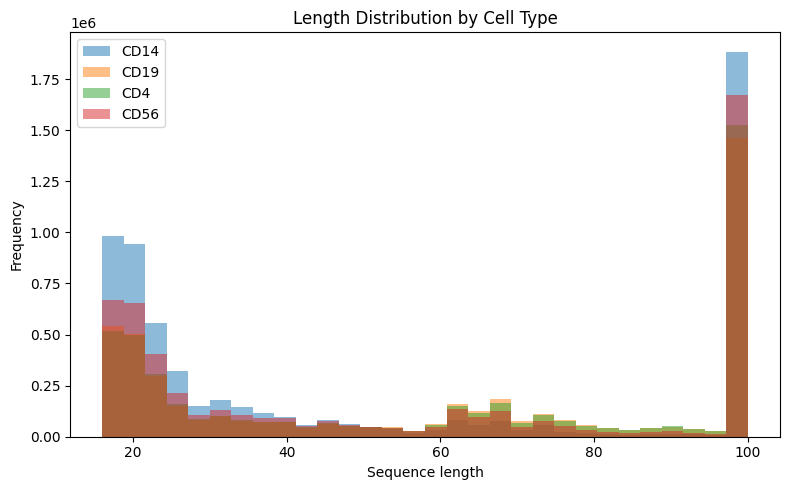

In [11]:
# ===== LENGTH BY CELL TYPE =====

plt.figure(figsize=(8,5))

for ct in sorted(seq_counts["cell_type"].unique()):
    subset = seq_counts[seq_counts["cell_type"] == ct]
    plt.hist(subset["length"], bins=30, alpha=0.5, label=ct)

plt.legend()
plt.title("Length Distribution by Cell Type")
plt.xlabel("Sequence length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

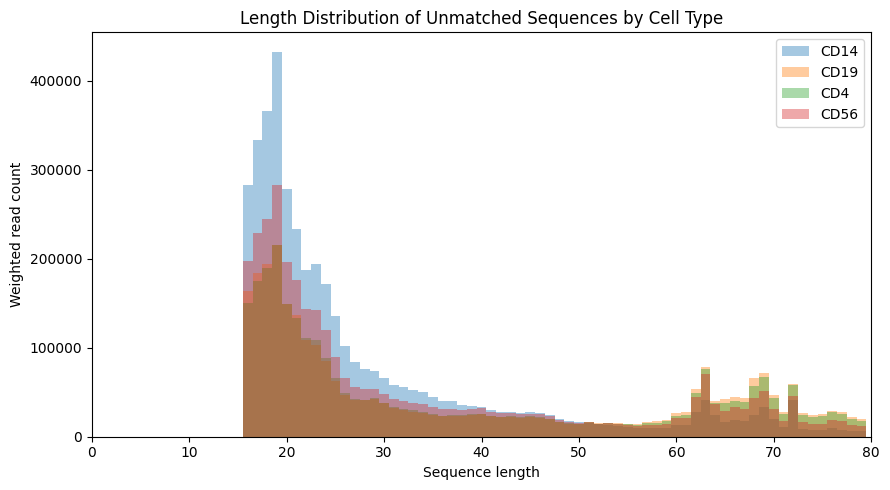

In [ ]:
# ===== FIXED LENGTH DISTRIBUTION BY CELL TYPE =====

plt.figure(figsize=(9,5))

for ct in sorted(seq_counts["cell_type"].unique()):
    subset = seq_counts[seq_counts["cell_type"] == ct]
    plt.hist(
        subset["length"],
        bins=np.arange(0, 81) - 0.5,
        weights=subset["count"],
        alpha=0.4,
        label=ct
    )

plt.xlim(0, 80)
plt.legend()
plt.title("Length Distribution of Unmatched Sequences by Cell Type")
plt.xlabel("Sequence length (nt)")
plt.ylabel("Weighted read count")
plt.tight_layout()
plt.show()

In [13]:
# ===== USRF LENGTH ANALYSIS FROM RAW RESIDUAL READS (8-20 nt focus) =====

from pathlib import Path
import gzip
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESID_DIR = PROJECT_DIR / "02.residual_reads"
fastq_files = sorted(RESID_DIR.glob("*.fastq.gz"))

print("Residual FASTQs found:", len(fastq_files))
for f in fastq_files[:20]:
    print(f.name)

def read_fastq_lengths_and_counts(path):
    lengths = []
    seqs = []
    with gzip.open(path, "rt") as fh:
        for i, line in enumerate(fh):
            if i % 4 == 1:
                seq = line.strip()
                seqs.append(seq)
                lengths.append(len(seq))
    return seqs, lengths

resid_tables = []

for fq in fastq_files:
    sample = fq.name.replace(".fastq.gz", "")
    seqs, lengths = read_fastq_lengths_and_counts(fq)
    c = Counter(seqs)

    df = pd.DataFrame({
        "sequence": list(c.keys()),
        "count": list(c.values())
    })
    df["length"] = df["sequence"].str.len()
    df["source_file"] = fq.name
    resid_tables.append(df)

resid_seq_counts = pd.concat(resid_tables, ignore_index=True)

print("resid_seq_counts shape:", resid_seq_counts.shape)
display(resid_seq_counts.head())
print(resid_seq_counts["length"].describe())

Residual FASTQs found: 0


ValueError: No objects to concatenate

In [14]:
from pathlib import Path

RESID_DIR = PROJECT_DIR / "02.residual_reads"
print("Exists:", RESID_DIR.exists())
print("Files:", list(RESID_DIR.glob("*"))[:20])

Exists: False
Files: []


In [15]:
# ===== FIND RESIDUAL FASTQS DIRECTLY FROM RUN_DIR =====

from pathlib import Path

fastq_files = sorted(set(
    list(RUN_DIR.rglob("*unmapped*.fastq.gz")) +
    list(RUN_DIR.rglob("*trimmed*.fastq.gz")) +
    [p for p in RUN_DIR.rglob("*.fastq.gz") if "fastp" in str(p)]
))

print("FASTQ files found:", len(fastq_files))
for f in fastq_files[:50]:
    print(f)

FASTQ files found: 80
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD14_S1.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD14_S2.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD14_S3.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD14_S4.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD19_S1.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD19_S2.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD19_S3.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD19_S4.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD4_S1.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD4_S2.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD4_S3.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.

In [16]:
# ===== BUILD resid_seq_counts FROM FASTQS FOUND IN RUN_DIR =====

import gzip
from collections import Counter
import pandas as pd

def read_fastq_sequences_gz(path):
    seqs = []
    with gzip.open(path, "rt") as fh:
        for i, line in enumerate(fh):
            if i % 4 == 1:
                seqs.append(line.strip())
    return seqs

resid_tables = []

for fq in fastq_files:
    seqs = read_fastq_sequences_gz(fq)
    if not seqs:
        continue

    counts = Counter(seqs)
    df = pd.DataFrame({
        "sequence": list(counts.keys()),
        "count": list(counts.values())
    })
    df["length"] = df["sequence"].str.len()
    df["source_file"] = fq.name
    resid_tables.append(df)

print("tables built:", len(resid_tables))

resid_seq_counts = pd.concat(resid_tables, ignore_index=True)
print("resid_seq_counts shape:", resid_seq_counts.shape)
display(resid_seq_counts.head())

tables built: 80
resid_seq_counts shape: (68014693, 4)


,sequence,count,length,source_file
0,ATGAAATGCTGGCAATCATCTTTCGGGACTGACCTGAAATGAAGAG...,1,64,CD14_S1.fail.fastq.gz
1,AGCTTATCAGACTGATGTTGACAAGCTCGAAAGATCACCCGCCTGA...,1,100,CD14_S1.fail.fastq.gz
2,CTTCTCACTACTGCACCTGACTAGACGATCGGAAGAGCACCAATCT...,1,100,CD14_S1.fail.fastq.gz
3,TGAGGTAGTAGTTTGTGCTGTTA,149,23,CD14_S1.fail.fastq.gz
4,CA,8992,2,CD14_S1.fail.fastq.gz


In [17]:
# ===== FIND ONLY BIOLOGICALLY RELEVANT RESIDUAL FASTQS =====

fastq_files = sorted(set(
    list(RUN_DIR.rglob("*unmapped*.fastq.gz")) +
    list(RUN_DIR.rglob("*trimmed*.fastq.gz"))
))

print("FASTQ files found:", len(fastq_files))
for f in fastq_files[:50]:
    print(f)

FASTQ files found: 64
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD14_S1_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD14_S2_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD14_S3_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD14_S4_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD19_S1_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD19_S2_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD19_S3_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD19_S4_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq

In [18]:
# ===== SELECT BEST USRF INPUT =====

fastq_files = sorted(
    RUN_DIR.rglob("*mature_hairpin_genome.unmapped.fastq.gz")
)

print("Genome-unmapped FASTQs:", len(fastq_files))
for f in fastq_files[:20]:
    print(f)

Genome-unmapped FASTQs: 16
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD14_S1_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD14_S2_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD14_S3_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD14_S4_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD19_S1_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD19_S2_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD19_S3_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/genome_quant/bam/CD19_S4_mature_hairpin_genome.unmapped.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smr

In [19]:
usrf = resid_seq_counts[
    (resid_seq_counts["length"] >= 8) &
    (resid_seq_counts["length"] <= 20)
].copy()

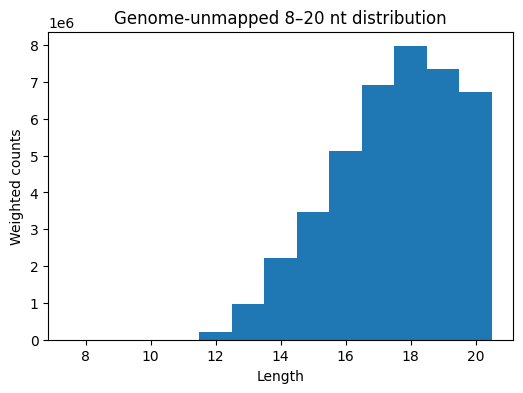

In [20]:
plt.figure(figsize=(6,4))
plt.hist(
    usrf["length"],
    bins=np.arange(8,22)-0.5,
    weights=usrf["count"]
)
plt.title("Genome-unmapped 8–20 nt distribution")
plt.xlabel("Length")
plt.ylabel("Weighted counts")
plt.show()

In [ ]:
usrf_candidates = (
    usrf.groupby("sequence")
    .agg(
        total_count=("count", "sum"),
        n_samples=("source_file", "nunique"),
        length=("length", "first")
    )
    .reset_index()
    .sort_values(["n_samples", "total_count"], ascending=[False, False])
)

display(usrf_candidates.head(250))

,sequence,total_count,n_samples,length
3135910,TGCACTTGTCCCGGCCTTAA,494,65,20
258215,ACCGGGCGGAAACACCAA,513164,64,18
258214,ACCGGGCGGAAACACCA,435671,64,17
2975611,TCTCGCTGGGGCCTCCAA,324356,64,18
2921286,TCCGGCTCGAAGGACCA,263761,64,17
...,...,...,...,...
2977900,TCTCGGTGGGACCTCCATTA,3205,50,20
1232724,CCGGTCAGGGAACCAA,3036,50,16
1380411,CGCGGAGTCTGGAAGTGA,2988,50,18
1278256,CCTGTTCGGGCGCCAA,2974,50,16


In [24]:
# ===== REBUILD resid_seq_counts WITH sample + cell_type =====

import re
import gzip
from collections import Counter
import pandas as pd

def read_fastq_sequences_gz(path):
    seqs = []
    with gzip.open(path, "rt") as fh:
        for i, line in enumerate(fh):
            if i % 4 == 1:
                seqs.append(line.strip())
    return seqs

resid_tables = []

for fq in fastq_files:
    seqs = read_fastq_sequences_gz(fq)
    if not seqs:
        continue

    counts = Counter(seqs)
    df = pd.DataFrame({
        "sequence": list(counts.keys()),
        "count": list(counts.values())
    })
    df["length"] = df["sequence"].str.len()
    df["source_file"] = fq.name

    m = re.search(r"(CD(?:14|19|4|56)_S\d+)", fq.name)
    df["sample"] = m.group(1) if m else fq.name
    df["cell_type"] = df["sample"].str.split("_").str[0]

    resid_tables.append(df)

resid_seq_counts = pd.concat(resid_tables, ignore_index=True)

print(resid_seq_counts.columns.tolist())
display(resid_seq_counts.head())

['sequence', 'count', 'length', 'source_file', 'sample', 'cell_type']


,sequence,count,length,source_file,sample,cell_type
0,TAGCTTATCAGACTGATGTTGACAAGATCGGAAGAGCACACGTTCT...,1,100,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14
1,GGTAGTAGATTGTATAGTAGATCGGAAGGACACGTCTGAACTCCAG...,1,100,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14
2,TGAGGTAGTAGTTTGTACTGTTAA,620,24,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14
3,TAGCTTATCAGACTGATGTTGATTCAAGTAATTCAGGATAGGTTA,82,45,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14
4,TTCAGGTAATCCAGGATAGGCCA,434,23,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14


In [25]:
# ===== REBUILD usrf =====

usrf = resid_seq_counts[
    (resid_seq_counts["length"] >= 8) &
    (resid_seq_counts["length"] <= 20)
].copy()

print(usrf.columns.tolist())
display(usrf.head())

['sequence', 'count', 'length', 'source_file', 'sample', 'cell_type']


,sequence,count,length,source_file,sample,cell_type
1033,TGCACTCGTCTCGGTCTGTA,1,20,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14
1074,GTCTCGTCGCGCGCGTTA,45,18,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14
1216,ACCGGGCGGAAACACCATTA,890,20,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14
1333,CACCAAGCTCGGACAAGGTA,2,20,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14
1553,GACTGCCATCTACGAGAGCA,1,20,CD14_S1_mature_hairpin_genome.unmapped.fastq.gz,CD14_S1,CD14


In [26]:
# ===== USRF CANDIDATE TABLE WITH BOTH APPEARANCE COLUMNS =====

usrf_candidates = (
    usrf.groupby("sequence")
    .agg(
        total_count=("count", "sum"),
        file_appearance=("source_file", "nunique"),
        sample_appearance=("sample", "nunique"),
        cell_type_appearance=("cell_type", "nunique"),
        length=("length", "first")
    )
    .reset_index()
    .sort_values(
        ["sample_appearance", "total_count"],
        ascending=[False, False]
    )
)

display(usrf_candidates.head(20))

,sequence,total_count,file_appearance,sample_appearance,cell_type_appearance,length
427,ACCGGGCGGAAACACCATTA,7489,16,16,4,20
289,ACAGTGGCTAAGTTCCGTTA,246,16,16,4,20
5271,TGCACTTGTCCCGGCCTTAA,159,16,16,4,20
1206,ATCCGGCTCGGAGGACCAA,110,16,16,4,19
4185,GGTCGTCGATTGTATAGTTA,85,16,16,4,20
5613,TTCCACCTTTCGGGCGCCAA,34,16,16,4,20
5254,TGCACTTGTCCCGGCCAATA,97,15,15,4,20
710,AGAATAGAACGCGCAGGGGA,79,15,15,4,20
4199,GGTCGTCGGTTGTATAGTTA,69,15,15,4,20
5720,TTCTACAGTCCGACGATCTA,68,15,15,4,20


In [30]:
display(usrf_candidates.query("length <= 17").head(20))

,sequence,total_count,file_appearance,sample_appearance,cell_type_appearance,length
2835,CGTCTCGTCGCGCGTTA,17,5,5,3,17
5069,TCTCGTCGCGCGCGTTA,12,5,5,3,17
574,ACGTCTCGTCGCGCTTA,1,1,1,1,17
576,ACGTCTCGTTGCGCGTA,1,1,1,1,17
873,AGCNCCGTCGTCGTCAA,1,1,1,1,17
1258,ATCGCTCGCGGTCGCTA,1,1,1,1,17
2257,CGATTAGGATTCGGCGA,1,1,1,1,17
2834,CGTCTCGTCGCGCGTAA,1,1,1,1,17
3718,GCGNGGGACGGACCGAA,1,1,1,1,17
4357,GTCCGACGATCCGATTA,1,1,1,1,17


In [31]:
# ===== ADD SAMPLE / CELL TYPE LISTS =====

sample_lists = (
    usrf.groupby("sequence")["sample"]
    .apply(lambda x: ",".join(sorted(set(x))))
    .reset_index(name="samples")
)

celltype_lists = (
    usrf.groupby("sequence")["cell_type"]
    .apply(lambda x: ",".join(sorted(set(x))))
    .reset_index(name="cell_types")
)

usrf_candidates = usrf_candidates.merge(sample_lists, on="sequence")
usrf_candidates = usrf_candidates.merge(celltype_lists, on="sequence")

display(usrf_candidates.head(20))

,sequence,total_count,file_appearance,sample_appearance,cell_type_appearance,length,samples,cell_types
0,ACCGGGCGGAAACACCATTA,7489,16,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
1,ACAGTGGCTAAGTTCCGTTA,246,16,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
2,TGCACTTGTCCCGGCCTTAA,159,16,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
3,ATCCGGCTCGGAGGACCAA,110,16,16,4,19,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
4,GGTCGTCGATTGTATAGTTA,85,16,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
5,TTCCACCTTTCGGGCGCCAA,34,16,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
6,TGCACTTGTCCCGGCCAATA,97,15,15,4,20,"CD14_S1,CD14_S3,CD14_S4,CD19_S1,CD19_S2,CD19_S...","CD14,CD19,CD4,CD56"
7,AGAATAGAACGCGCAGGGGA,79,15,15,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S2,CD19_S...","CD14,CD19,CD4,CD56"
8,GGTCGTCGGTTGTATAGTTA,69,15,15,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
9,TTCTACAGTCCGACGATCTA,68,15,15,4,20,"CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S2,CD19_S...","CD14,CD19,CD4,CD56"


In [32]:
# ===== FIND FASTP OUTPUT FASTQS =====
# What this shows:
# This lists the post-fastp FASTQ files that are the best place to inspect
# the full 8–20 nt pool before downstream mapping filters remove short reads.

fastp_files = sorted([p for p in RUN_DIR.rglob("*.fastq.gz") if "/fastp/" in str(p)])

print("FASTP FASTQs found:", len(fastp_files))
for f in fastp_files[:50]:
    print(f)

FASTP FASTQs found: 16
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD14_S1.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD14_S2.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD14_S3.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD14_S4.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD19_S1.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD19_S2.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD19_S3.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD19_S4.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD4_S1.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD4_S2.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq/fastp/on_raw/CD4_S3.fail.fastq.gz
/samurlab1/Joshua/smallRNA_USRF/01

In [33]:
# ===== BUILD TABLE FROM FASTP OUTPUTS =====
# What this shows:
# This creates a sequence-level table from post-fastp reads, which should retain
# the full population allowed by your min length cutoff of 8 nt.

import re
import gzip
from collections import Counter
import pandas as pd

def read_fastq_sequences_gz(path):
    seqs = []
    with gzip.open(path, "rt") as fh:
        for i, line in enumerate(fh):
            if i % 4 == 1:
                seqs.append(line.strip())
    return seqs

fastp_tables = []

for fq in fastp_files:
    seqs = read_fastq_sequences_gz(fq)
    if not seqs:
        continue

    counts = Counter(seqs)
    df = pd.DataFrame({
        "sequence": list(counts.keys()),
        "count": list(counts.values())
    })
    df["length"] = df["sequence"].str.len()
    df["source_file"] = fq.name

    m = re.search(r"(CD(?:14|19|4|56)_S\d+)", fq.name)
    df["sample"] = m.group(1) if m else fq.name
    df["cell_type"] = df["sample"].str.split("_").str[0]

    fastp_tables.append(df)

fastp_seq_counts = pd.concat(fastp_tables, ignore_index=True)

print("fastp_seq_counts shape:", fastp_seq_counts.shape)
display(fastp_seq_counts.head())
print(fastp_seq_counts["length"].describe())

fastp_seq_counts shape: (507472, 6)


,sequence,count,length,source_file,sample,cell_type
0,ATGAAATGCTGGCAATCATCTTTCGGGACTGACCTGAAATGAAGAG...,1,64,CD14_S1.fail.fastq.gz,CD14_S1,CD14
1,AGCTTATCAGACTGATGTTGACAAGCTCGAAAGATCACCCGCCTGA...,1,100,CD14_S1.fail.fastq.gz,CD14_S1,CD14
2,CTTCTCACTACTGCACCTGACTAGACGATCGGAAGAGCACCAATCT...,1,100,CD14_S1.fail.fastq.gz,CD14_S1,CD14
3,TGAGGTAGTAGTTTGTGCTGTTA,149,23,CD14_S1.fail.fastq.gz,CD14_S1,CD14
4,CA,8992,2,CD14_S1.fail.fastq.gz,CD14_S1,CD14


count    507472.000000
mean         80.149001
std          32.628234
min           0.000000
25%          68.000000
50%         100.000000
75%         100.000000
max         100.000000
Name: length, dtype: float64


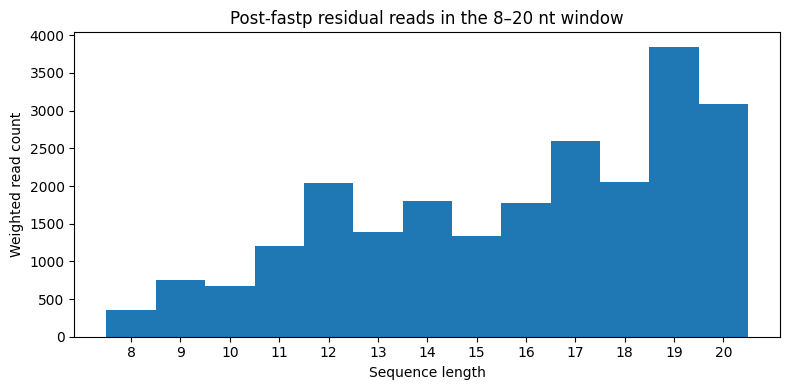

In [34]:
# ===== 8–20 nt FASTP DISTRIBUTION =====
# What this graph shows:
# This shows whether the post-fastp residual pool actually contains the short
# 8–20 nt molecules you expect for USRFs. If there is strong signal below 15 nt
# here, then those reads are being lost later by downstream mapping/filtering.

usrf_fastp = fastp_seq_counts[
    (fastp_seq_counts["length"] >= 8) &
    (fastp_seq_counts["length"] <= 20)
].copy()

plt.figure(figsize=(8,4))
plt.hist(
    usrf_fastp["length"],
    bins=np.arange(8, 22) - 0.5,
    weights=usrf_fastp["count"]
)
plt.xticks(range(8, 21))
plt.xlabel("Sequence length")
plt.ylabel("Weighted read count")
plt.title("Post-fastp residual reads in the 8–20 nt window")
plt.tight_layout()
plt.show()

In [35]:
# ===== FASTP-BASED USRF TABLE =====
# What this shows:
# This builds a sequence-level table of all reads in the 8–20 nt window
# directly from fastp outputs (before mapping filters remove short reads).

usrf_fastp = fastp_seq_counts[
    (fastp_seq_counts["length"] >= 8) &
    (fastp_seq_counts["length"] <= 20)
].copy()

fastp_candidates = (
    usrf_fastp.groupby("sequence")
    .agg(
        total_count=("count", "sum"),
        sample_appearance=("sample", "nunique"),
        cell_type_appearance=("cell_type", "nunique"),
        length=("length", "first")
    )
    .reset_index()
    .sort_values(
        ["sample_appearance", "total_count"],
        ascending=[False, False]
    )
)

display(fastp_candidates.head(50))

,sequence,total_count,sample_appearance,cell_type_appearance,length
8980,GCTTATCAGACTGATGTTGA,331,16,4,20
1589,AGCACCATCTGA,140,16,4,12
9750,GGTAGTAGATTGTATAGTTA,135,16,4,20
7553,CTTATCAGACTGATGTTGAA,113,16,4,20
1239,ACTTATCAGACTGATGTTGA,108,16,4,20
778,ACCGGGCGGAAACACCAA,98,16,4,18
777,ACCGGGCGGAAACACCA,97,16,4,17
13330,TTCAGGATAGGTTA,93,16,4,14
9774,GGTAGTAGGTTGTATAGTTA,92,16,4,20
517,ACAGTACTGTGATAACTGAA,84,16,4,20


In [36]:
# ===== ADD CONTEXT =====
# What this shows:
# This adds which samples and cell types each sequence appears in,
# making it possible to detect specificity or ubiquity.

sample_lists = (
    usrf_fastp.groupby("sequence")["sample"]
    .apply(lambda x: ",".join(sorted(set(x))))
    .reset_index(name="samples")
)

celltype_lists = (
    usrf_fastp.groupby("sequence")["cell_type"]
    .apply(lambda x: ",".join(sorted(set(x))))
    .reset_index(name="cell_types")
)

fastp_candidates = fastp_candidates.merge(sample_lists, on="sequence")
fastp_candidates = fastp_candidates.merge(celltype_lists, on="sequence")

display(fastp_candidates.head(50))

,sequence,total_count,sample_appearance,cell_type_appearance,length,samples,cell_types
0,GCTTATCAGACTGATGTTGA,331,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
1,AGCACCATCTGA,140,16,4,12,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
2,GGTAGTAGATTGTATAGTTA,135,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
3,CTTATCAGACTGATGTTGAA,113,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
4,ACTTATCAGACTGATGTTGA,108,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
5,ACCGGGCGGAAACACCAA,98,16,4,18,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
6,ACCGGGCGGAAACACCA,97,16,4,17,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
7,TTCAGGATAGGTTA,93,16,4,14,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
8,GGTAGTAGGTTGTATAGTTA,92,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"
9,ACAGTACTGTGATAACTGAA,84,16,4,20,"CD14_S1,CD14_S2,CD14_S3,CD14_S4,CD19_S1,CD19_S...","CD14,CD19,CD4,CD56"


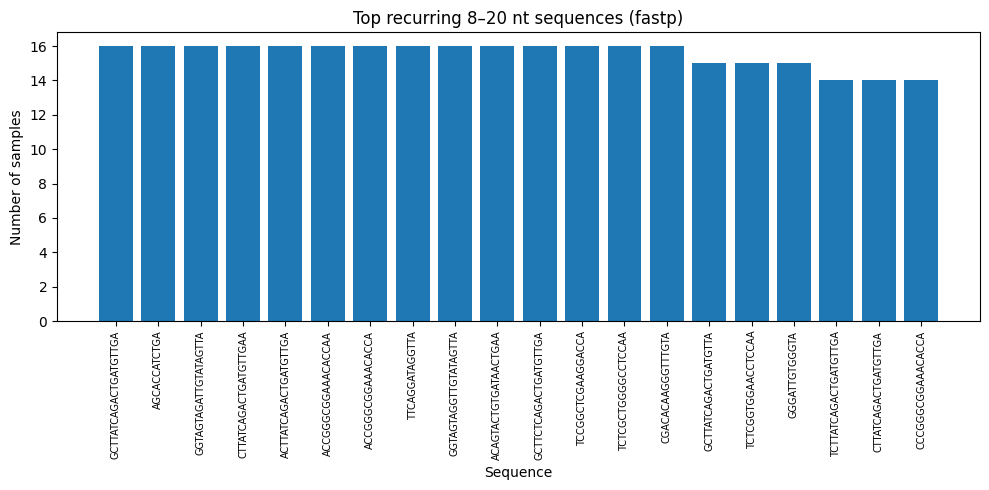

In [37]:
# ===== SAMPLE RECURRENCE =====
# What this shows:
# This shows how consistently each sequence appears across biological samples.
# Sequences present in many samples are stronger candidates than one-offs.

top = fastp_candidates.head(20)

plt.figure(figsize=(10,5))
plt.bar(range(len(top)), top["sample_appearance"])
plt.xticks(range(len(top)), top["sequence"], rotation=90, fontsize=7)
plt.ylabel("Number of samples")
plt.xlabel("Sequence")
plt.title("Top recurring 8–20 nt sequences (fastp)")
plt.tight_layout()
plt.show()